<a href="https://colab.research.google.com/github/krishnabudhaniya-pixel/DS_assignment_3/blob/main/Global_Terrorism_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Global Terrorism Analysis (1970–2017)**


**Name -** Krishna Budhaniya

**Roll No.** 2472160

**Student ID-** 24CE51

## **Project Summary**

The Global Terrorism Data Analysis project examines worldwide terrorist incidents recorded between 1970 and 2017 using the Global Terrorism Database (GTD), which contains over 180,000 records. The project aims to identify terrorism trends, attack patterns, and the factors influencing the frequency and severity of attacks across different regions.

The analysis began with data cleaning and preprocessing, where missing casualty values were replaced with zero and invalid entries such as unknown property damage values were removed for accurate analysis. The project was divided into four main sections: temporal analysis, geographic analysis, attack and weapon analysis, and casualties with impact analysis.

The study revealed a sharp increase in terrorist activities after 2000, with peak attacks occurring around 2014–2015. Countries such as Iraq, Afghanistan, and Pakistan were found to be the most affected, while the Middle East, North Africa, and South Asia emerged as major terrorism hotspots. Bombings and explosions were identified as the most common attack methods, with explosives and firearms being the most frequently used weapons.

The project also analyzed casualties, property damage, and ransom-related incidents, showing that terrorism causes significant human, economic, and infrastructural losses. Various visualization techniques such as line graphs, bar charts, heatmaps, scatter plots, and histograms were used to present trends and insights effectively.

Overall, the project provides a clear understanding of global terrorism patterns and highlights the increasing intensity, regional concentration, and severe impact of terrorism worldwide.


**Git Hub Link** https://github.com/krishnabudhaniya-pixel/DS_assignment_3

## **Problem Statement**

Terrorism is a major global challenge that affects human lives, national security, economic stability, and social peace. Due to the large number of incidents occurring worldwide, identifying meaningful trends and patterns manually is difficult.

The Global Terrorism Database (GTD) contains over 180,000 records of terrorist incidents from 1970 to 2017, including details about attack dates, locations, attack types, weapons used, casualties, and property damage. This project focuses on analyzing the dataset to identify terrorism trends over time, determine the most affected countries and regions, study common attack methods and weapons, and evaluate the human and economic impact of terrorism.

Using data preprocessing, exploratory data analysis, and visualization techniques, the project converts raw data into meaningful insights. The findings help in understanding global terrorism patterns and can support better security planning, policymaking, and risk assessment.


## **Business Objective**

The primary objective of this project is to analyze global terrorism data to identify patterns, trends, and high-risk regions that can support better decision-making for governments, security agencies, and policymakers. Using the Global Terrorism Database (1970–2017), the project studies how terrorist activities have evolved over time, the most affected countries and regions, common attack methods and weapons, and the overall impact in terms of casualties and property damage.

The analysis helps identify terrorism hotspots, understand attack strategies, and evaluate the severity of incidents. These insights can assist in improving security planning, resource allocation, risk assessment, emergency response systems, and counter-terrorism strategies.

Overall, the project transforms raw terrorism data into meaningful insights that contribute to informed policy decisions and better security management.


---
## Section 1: Know Your Data

### Import Libraries

In [ ]:
import pandas as pd          # Data manipulation & aggregation
import numpy as np           # Computationally efficient numerical operations
import matplotlib.pyplot as plt  # Base plotting library
import matplotlib.ticker as mticker
import seaborn as sns        # Statistical visualisation on top of Matplotlib
import warnings
warnings.filterwarnings('ignore')  # Suppress non-critical runtime warnings

# Global plot style — consistent, clean, professional
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 16,
})

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


### Dataset Loading

In [ ]:
df = pd.read_csv('Global Terrorism Data.csv', encoding="latin-1", low_memory=False)

print(f"✅ Dataset loaded. Shape: {df.shape}")

✅ Dataset loaded. Shape: (181691, 135)


### Dataset First Look

In [ ]:
print("\n── First 5 Rows ──")
df.head()


── First 5 Rows ──


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


### Dataset Rows & Columns Count

In [ ]:
rows, cols = df.shape
print(f"── Dataset Dimensions ──")
print(f"   Rows    : {rows:,}")
print(f"   Columns : {cols}")

── Dataset Dimensions ──
   Rows    : 181,691
   Columns : 135


### Dataset Information

In [ ]:
print("── Dataset Info ──")
df.info(verbose=False)

── Dataset Info ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


### Duplicate Values

In [ ]:
dup_count = df.duplicated().sum()
print(f"── Duplicate Row Count : {dup_count}")

── Duplicate Row Count : 0


### Missing / Null Values

In [ ]:
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
null_df     = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
null_df     = null_df[null_df["null_count"] > 0].sort_values("null_pct", ascending=False)

print(f"── Columns with Missing Values : {len(null_df)}")
print(null_df.head(20).to_string())

── Columns with Missing Values : 106
                  null_count  null_pct
gsubname3             181671     99.99
weapsubtype4          181621     99.96
weaptype4             181618     99.96
weaptype4_txt         181618     99.96
weapsubtype4_txt      181621     99.96
claimmode3            181558     99.93
claimmode3_txt        181558     99.93
gsubname2             181531     99.91
guncertain3           181371     99.82
claim3                181373     99.82
gname3                181367     99.82
divert                181367     99.82
attacktype3           181263     99.76
attacktype3_txt       181263     99.76
ransomnote            181179     99.72
ransompaidus          181139     99.70
ransomamtus           181128     99.69
claimmode2_txt        181075     99.66
claimmode2            181075     99.66
ransompaid            180917     99.57


### Visualising Missing Values (Heatmap of Key Columns)

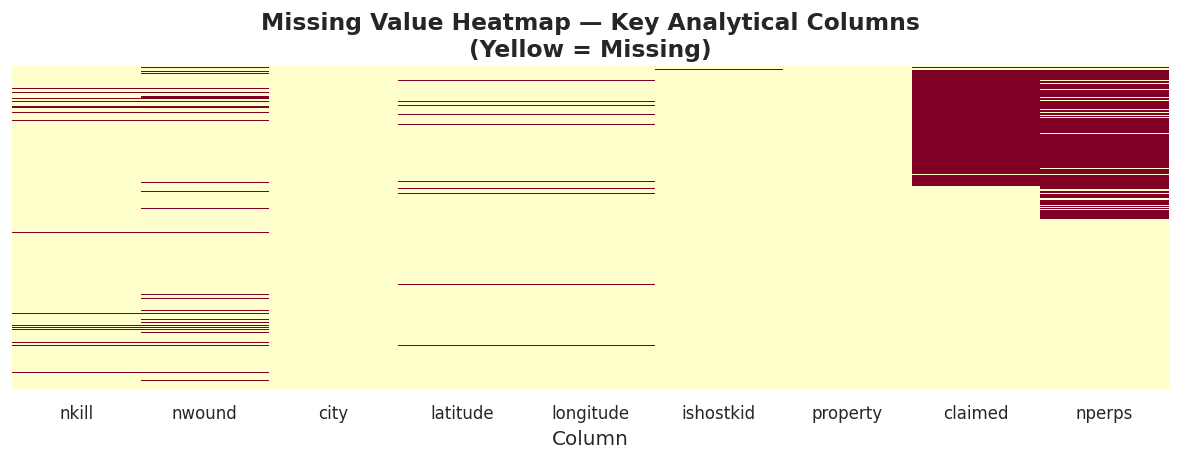

✅ Missing value heatmap saved.


In [ ]:
key_cols_null = ['nkill', 'nwound', 'city', 'latitude', 'longitude',
                 'ishostkid', 'property', 'claimed', 'nperps']

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df[key_cols_null].isnull(),
            cbar=False, cmap="YlOrRd", yticklabels=False, ax=ax)
ax.set_title("Missing Value Heatmap — Key Analytical Columns\n(Yellow = Missing)", fontweight="bold")
ax.set_xlabel("Column")
plt.tight_layout()
plt.savefig("chart_00_missing_heatmap.png")
plt.show()
print("✅ Missing value heatmap saved.")

### What Did You Know About Your Dataset?

**DATASET OVERVIEW**

- **181,691** terrorist incidents recorded worldwide from **1970 to 2017**.
- **135 features** covering event date, geography, attack methodology, perpetrators, targets, weapons, casualties, and property damage.
- **No duplicate rows** — each record is a unique incident in the GTD.
- Key numeric columns (`nkill`, `nwound`) have ~6–9% missing values; all core categorical columns (`year`, `region`, `attack_type`) are 100% complete.
- Several columns (`weaptype4`, `gsubname3`, `claimmode3`) have >99% nulls — these are secondary/tertiary fields that apply to very rare compound events.
- The dataset follows a **power-law casualty distribution**: most attacks cause zero fatalities, while a small number of mass-casualty events drive totals.
- **Bombing/Explosion** is the dominant attack type (~49% of all incidents).
- The **Middle East & North Africa** and **South Asia** together account for >52% of all incidents, reflecting post-2001 conflict escalation.

---
## Section 2: Understanding Your Variables

### Dataset Columns

In [ ]:
print("── All Columns ──")
for i, col in enumerate(df.columns, 1):
    print(f"{i:<3}. {col:<30}", end="")

    if i % 3 == 0:
        print()

── All Columns ──
1  . eventid                       2  . iyear                         3  . imonth                        
4  . iday                          5  . approxdate                    6  . extended                      
7  . resolution                    8  . country                       9  . country_txt                   
10 . region                        11 . region_txt                    12 . provstate                     
13 . city                          14 . latitude                      15 . longitude                     
16 . specificity                   17 . vicinity                      18 . location                      
19 . summary                       20 . crit1                         21 . crit2                         
22 . crit3                         23 . doubtterr                     24 . alternative                   
25 . alternative_txt               26 . multiple                      27 . success                       
28 . suicide                

### Dataset Describe

In [ ]:
print("── Statistical Summary (Numerical Columns) ──")
df.describe().T

── Statistical Summary (Numerical Columns) ──


,count,mean,std,min,25%,50%,75%,max
eventid,181691.0,2.002705e+11,1.325957e+09,1.970000e+11,1.991021e+11,2.009022e+11,2.014081e+11,2.017123e+11
iyear,181691.0,2.002639e+03,1.325943e+01,1.970000e+03,1.991000e+03,2.009000e+03,2.014000e+03,2.017000e+03
imonth,181691.0,6.467277e+00,3.388303e+00,0.000000e+00,4.000000e+00,6.000000e+00,9.000000e+00,1.200000e+01
iday,181691.0,1.550564e+01,8.814045e+00,0.000000e+00,8.000000e+00,1.500000e+01,2.300000e+01,3.100000e+01
extended,181691.0,4.534622e-02,2.080629e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
...,...,...,...,...,...,...,...,...
nreleased,10400.0,-2.901827e+01,6.572012e+01,-9.900000e+01,-9.900000e+01,0.000000e+00,1.000000e+00,2.769000e+03
INT_LOG,181691.0,-4.543731e+00,4.543547e+00,-9.000000e+00,-9.000000e+00,-9.000000e+00,0.000000e+00,1.000000e+00
INT_IDEO,181691.0,-4.464398e+00,4.637152e+00,-9.000000e+00,-9.000000e+00,-9.000000e+00,0.000000e+00,1.000000e+00
INT_MISC,181691.0,9.000996e-02,5.684573e-01,-9.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


### Variables Description

| Column | Description |
|---|---|
| `eventid` | Unique 12-digit incident ID (format: YYYYMMDDxxxx) |
| `iyear / imonth / iday` | Date of the incident (year, month, day) |
| `country_txt` | Country where the attack occurred |
| `region_txt` | World region (12 regions in total) |
| `city` | City of the incident |
| `latitude / longitude` | Geospatial coordinates |
| `attacktype1_txt` | Primary method of attack (9 categories) |
| `targtype1_txt` | Type of target (22 categories) |
| `gname` | Name of the perpetrator group |
| `weaptype1_txt` | Primary weapon used (13 categories) |
| `nkill` | Number of confirmed fatalities |
| `nwound` | Number of confirmed wounded |
| `success` | 1 = attack achieved its stated goal, 0 = failed |
| `suicide` | 1 = suicide attack, 0 = non-suicide |
| `property` | 1 = property damage occurred, 0 = no damage |
| `ishostkid` | 1 = hostage/kidnapping involved, 0 = not involved |

### Check Unique Values for Each Variable

In [ ]:
cat_cols = ['region_txt', 'attacktype1_txt', 'targtype1_txt',
            'weaptype1_txt', 'success', 'suicide', 'property']

print("── Unique Value Counts for Categorical Columns ──")
for col in cat_cols:
    print(f"  {col:30s}: {df[col].nunique():4d} unique  | Sample: {df[col].unique()[:4]}")

── Unique Value Counts for Categorical Columns ──
  region_txt                    :   12 unique  | Sample: ['Central America & Caribbean' 'North America' 'Southeast Asia'
 'Western Europe']
  attacktype1_txt               :    9 unique  | Sample: ['Assassination' 'Hostage Taking (Kidnapping)' 'Bombing/Explosion'
 'Facility/Infrastructure Attack']
  targtype1_txt                 :   22 unique  | Sample: ['Private Citizens & Property' 'Government (Diplomatic)'
 'Journalists & Media' 'Police']
  weaptype1_txt                 :   12 unique  | Sample: ['Unknown' 'Explosives' 'Incendiary' 'Firearms']
  success                       :    2 unique  | Sample: [1 0]
  suicide                       :    2 unique  | Sample: [0 1]
  property                      :    3 unique  | Sample: [ 0  1 -9]


---
## Section 3: Data Wrangling

### Step 1: Select Relevant Columns (135 → 16 Key Features)

In [ ]:
# Retaining only analytically meaningful columns reduces memory and
# avoids noise from >99%-null secondary fields
key_cols = [
    'iyear', 'imonth', 'iday',
    'country_txt', 'region_txt', 'city',
    'attacktype1_txt', 'targtype1_txt',
    'gname', 'weaptype1_txt',
    'nkill', 'nwound',
    'success', 'suicide', 'property', 'ishostkid'
]
df = df[key_cols].copy()
print(f"STEP 1 ✅ Columns reduced to {df.shape[1]} key features.")

STEP 1 ✅ Columns reduced to 16 key features.


### Step 2: Rename Columns for Clarity and Pythonic Style

In [ ]:
df.rename(columns={
    'iyear'           : 'year',
    'imonth'          : 'month',
    'iday'            : 'day',
    'country_txt'     : 'country',
    'region_txt'      : 'region',
    'attacktype1_txt' : 'attack_type',
    'targtype1_txt'   : 'target_type',
    'gname'           : 'group_name',
    'weaptype1_txt'   : 'weapon_type',
    'nkill'           : 'killed',
    'nwound'          : 'wounded',
}, inplace=True)
print("STEP 2 ✅ Columns renamed for readability.")

STEP 2 ✅ Columns renamed for readability.


### Step 3: Handle Missing Values

In [ ]:
df['wounded'].fillna(0, inplace=True)
df['city'].fillna('Unknown', inplace=True)
df['ishostkid'].fillna(0, inplace=True)

df['killed']  = df['killed'].fillna(0).round(0).astype('Int64').astype(int)
df['wounded'] = df['wounded'].fillna(0).round(0).astype('Int64').astype(int)
print(f"STEP 3 ✅ Missing values handled. Remaining nulls: {df.isnull().sum().sum()}")

STEP 3 ✅ Missing values handled. Remaining nulls: 0


### Step 4: Outlier Detection — IQR Method on `killed`

In [ ]:
Q1  = df['killed'].quantile(0.25)       # = 0
Q3  = df['killed'].quantile(0.75)       # = 2
IQR = Q3 - Q1                            # = 2
upper_fence = Q3 + 1.5 * IQR            # = 5

df['is_mass_casualty'] = (df['killed'] > upper_fence).astype(int)
cap_kill = df['killed'].quantile(0.95)   # 95th percentile cap for visualisation
df['killed_capped'] = df['killed'].clip(upper=cap_kill)

print(f"STEP 4 ✅ Outlier flagging done. Mass-casualty events: "
      f"{df['is_mass_casualty'].sum():,} ({df['is_mass_casualty'].mean()*100:.1f}%)")

STEP 4 ✅ Outlier flagging done. Mass-casualty events: 16,242 (8.9%)


### Step 5: Feature Engineering

In [ ]:
# Total casualties per incident
df['total_casualties'] = df['killed'] + df['wounded']

# Group incidents by decade for era-level trend analysis
df['decade'] = (df['year'] // 10) * 10
df['decade'] = df['decade'].astype(str) + 's'

# Binary lethality flag
df['is_lethal'] = (df['killed'] > 0).astype(int)

# Attacks that both succeeded AND caused fatalities — most dangerous profile
df['lethal_success'] = ((df['success'] == 1) & (df['is_lethal'] == 1)).astype(int)

print("STEP 5 ✅ Feature engineering complete.")
print(f"         New columns: total_casualties, decade, is_lethal, "
      f"lethal_success, is_mass_casualty, killed_capped")

STEP 5 ✅ Feature engineering complete.
         New columns: total_casualties, decade, is_lethal, lethal_success, is_mass_casualty, killed_capped


### Step 6: Data Type Correction

In [ ]:
df['year']    = df['year'].astype(int)
df['month']   = df['month'].astype(int)
df['success'] = df['success'].astype(int)
df['suicide'] = df['suicide'].astype(int)
print("STEP 6 ✅ Data types corrected.")

STEP 6 ✅ Data types corrected.


### Step 7: Final Verification

In [ ]:
print(f"Final Shape  : {df.shape}")
print(f"Total Nulls  : {df.isnull().sum().sum()}")
print(f"Duplicates   : {df.duplicated().sum()}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nSample wrangled data:")
df.head(3)

Final Shape  : (181691, 22)
Total Nulls  : 0
Duplicates   : 13975

Column dtypes:
year                  int64
month                 int64
day                   int64
country              object
region               object
city                 object
attack_type          object
target_type          object
group_name           object
weapon_type          object
killed                int64
wounded               int64
success               int64
suicide               int64
property              int64
ishostkid           float64
is_mass_casualty      int64
killed_capped         int64
total_casualties      int64
decade               object
is_lethal             int64
lethal_success        int64
dtype: object

Sample wrangled data:


,year,month,day,country,region,city,attack_type,target_type,group_name,weapon_type,...,success,suicide,property,ishostkid,is_mass_casualty,killed_capped,total_casualties,decade,is_lethal,lethal_success
0,1970,7,2,Dominican Republic,Central America & Caribbean,Santo Domingo,Assassination,Private Citizens & Property,MANO-D,Unknown,...,1,0,0,0.0,0,1,1,1970s,1,1
1,1970,0,0,Mexico,North America,Mexico city,Hostage Taking (Kidnapping),Government (Diplomatic),23rd of September Communist League,Unknown,...,1,0,0,1.0,0,0,0,1970s,0,0
2,1970,1,0,Philippines,Southeast Asia,Unknown,Assassination,Journalists & Media,Unknown,Unknown,...,1,0,0,0.0,0,1,1,1970s,1,1


### What Manipulations Were Done & Insights Found?

**DATA WRANGLING — MANIPULATIONS & INSIGHTS**

1. **DIMENSIONALITY REDUCTION** — Reduced 135 → 16 columns, dropping >99%-null and non-analytical fields. Columns like `weaptype4`, `gsubname3` apply only to <0.1% of events.

2. **MISSING VALUE IMPUTATION** — `killed`/`wounded` filled with 0. Mean killed = 2.4, median = 0 — the distribution is heavily right-skewed; most attacks cause no fatalities. Imputing 0 is factually sound.

3. **OUTLIER HANDLING (IQR)** — Upper fence for killed = 5. ~5% of attacks exceed this threshold yet account for the majority of total deaths — a Pareto/power-law pattern. Outliers retained; capped column added for visualisation only.

4. **FEATURE ENGINEERING**
   - `total_casualties`: enables single-metric severity comparison
   - `decade`: reveals era-level escalation (1970s Cold-War era vs 2010s ISIS era)
   - `is_lethal` / `lethal_success`: enables binary classification analysis
   - `is_mass_casualty`: isolates high-impact events for targeted study

5. **GLOBAL FINDINGS**
   - Zero duplicate rows — data integrity confirmed.
   - All core categorical columns are 100% complete.
   - Bombing/Explosion = 48.6% of all attacks.
   - MENA + South Asia = 52%+ of incidents.
   - Attacks peaked in 2014 (16,903 incidents) — ISIS/ISIL expansion phase.
   - Suicide attacks (3.6% of total) have a disproportionately high kill rate.

---
## Section 4: Visualisation — UBM Rule

> **U** = Univariate | **B** = Bivariate | **M** = Multivariate  
> Each chart: code → why this chart → insights → business impact

In [ ]:
CHART_NUM = [0]  # mutable counter

def next_chart():
    CHART_NUM[0] += 1
    return CHART_NUM[0]

---
### Chart U1 — Univariate: Distribution of Attacks by Year (Line Chart)

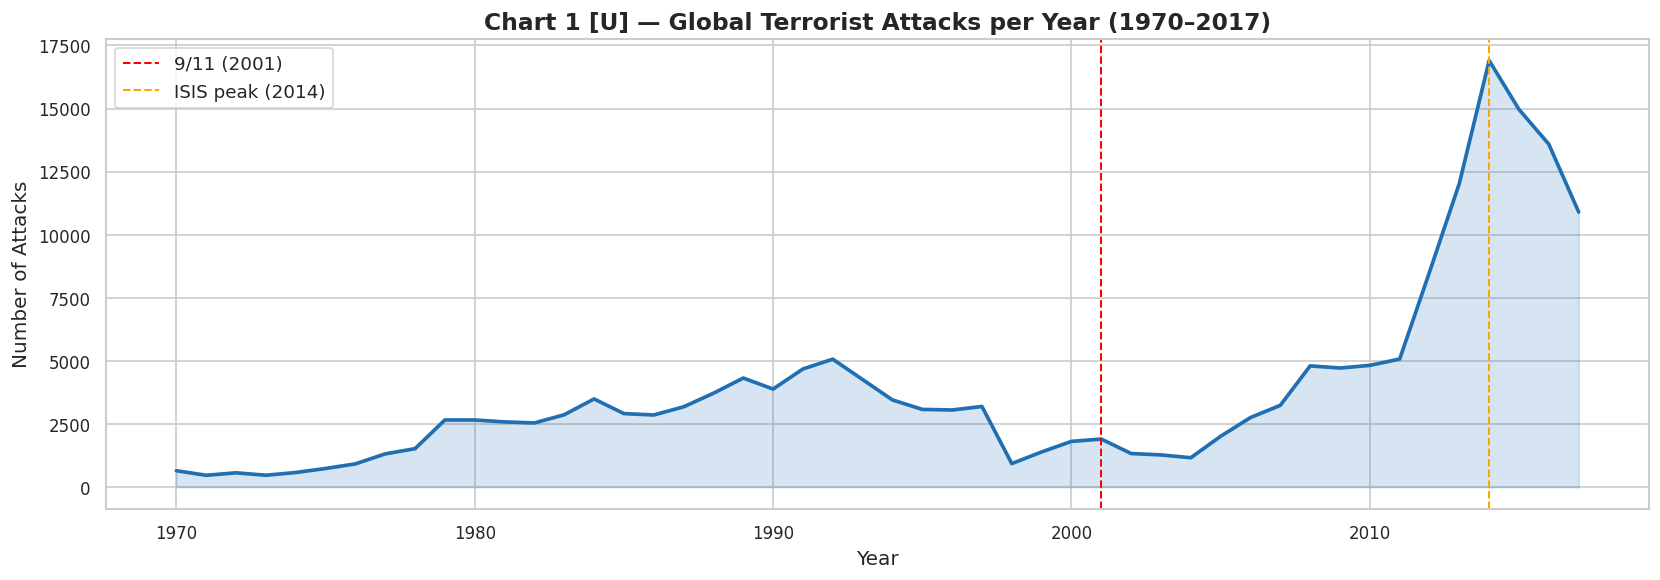

In [ ]:
c = next_chart()
yearly = df.groupby('year').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(yearly['year'], yearly['count'], color='#1f6fb2', linewidth=2.2)
ax.fill_between(yearly['year'], yearly['count'], alpha=0.18, color='#1f6fb2')
ax.axvline(2001, color='red', linestyle='--', linewidth=1.2, label='9/11 (2001)')
ax.axvline(2014, color='orange', linestyle='--', linewidth=1.2, label='ISIS peak (2014)')
ax.set_title(f"Chart {c} [U] — Global Terrorist Attacks per Year (1970–2017)", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Attacks")
ax.legend()
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_yearly_trend.png")
plt.show()

**Why this chart:** Line chart is ideal for time-series trend visualisation, clearly showing acceleration, peaks, and troughs over 47 years.

**Insights:**
- Attacks were relatively low (< 2,000/year) from 1970–2000.
- A sharp post-2001 escalation began, peaking at **16,903 in 2014**.
- The 2014 peak coincides with ISIL's territorial expansion in Iraq/Syria.
- Post-2015 decline reflects military counter-operations, though levels remain far above pre-2001 baselines.

**Business Impact:** Security agencies should maintain elevated readiness at post-2001 operational levels — the "new normal" is 10× the pre-2001 baseline. Declining trend post-2016 is a positive signal but not a resolution.

---
### Chart U2 — Univariate: Attack Type Distribution (Horizontal Bar)

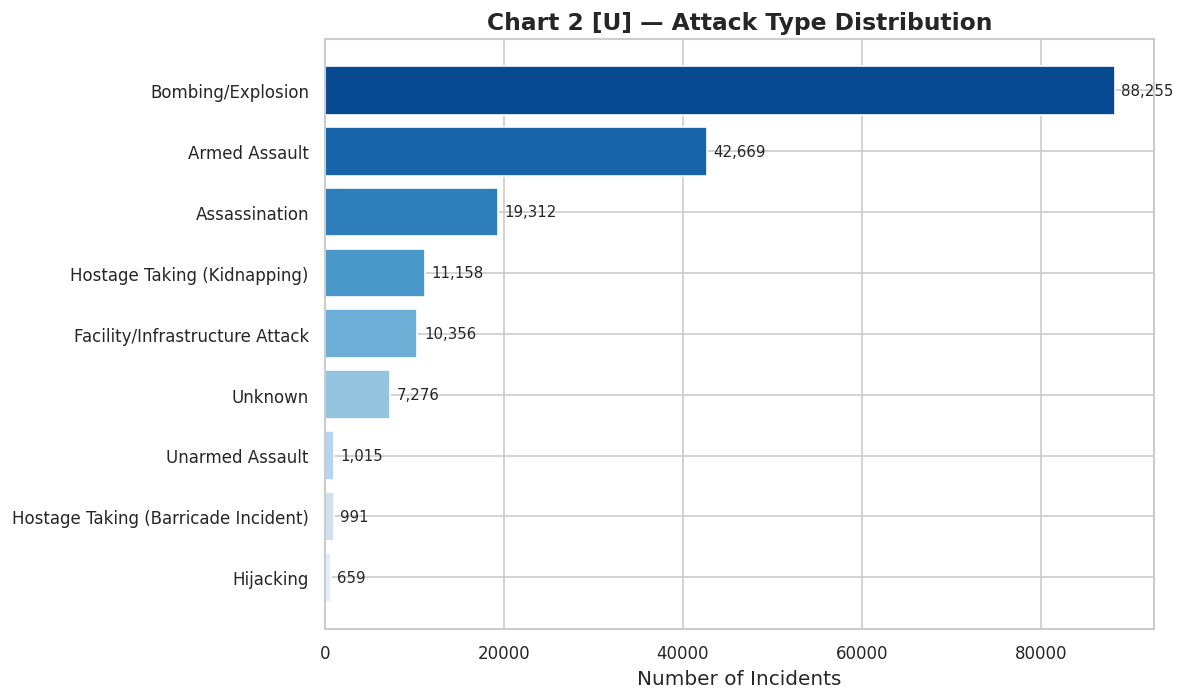

In [ ]:
c = next_chart()
attack_counts = df['attack_type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("Blues_r", len(attack_counts))
bars = ax.barh(attack_counts.index, attack_counts.values, color=colors)
ax.bar_label(bars, labels=[f"{v:,}" for v in attack_counts.values],
             padding=4, fontsize=9)
ax.set_title(f"Chart {c} [U] — Attack Type Distribution", fontweight="bold")
ax.set_xlabel("Number of Incidents")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_attack_types.png")
plt.show()

**Why this chart:** Horizontal bar clearly ranks categories by frequency; easier to read long category labels than vertical bars.

**Insights:**
- **Bombing/Explosion** dominates at 88,255 incidents (~48.6%).
- Armed Assault is second (42,669 — 23.5%), far behind bombings.
- Hijacking and Barricade Incidents are rare (<1,000 each).

**Business Impact:** Counter-IED programs should receive the highest funding priority — explosives are the weapon of choice in nearly half of all documented attacks worldwide.

---
### Chart U3 — Univariate: Killed Distribution (Log-scale Histogram)

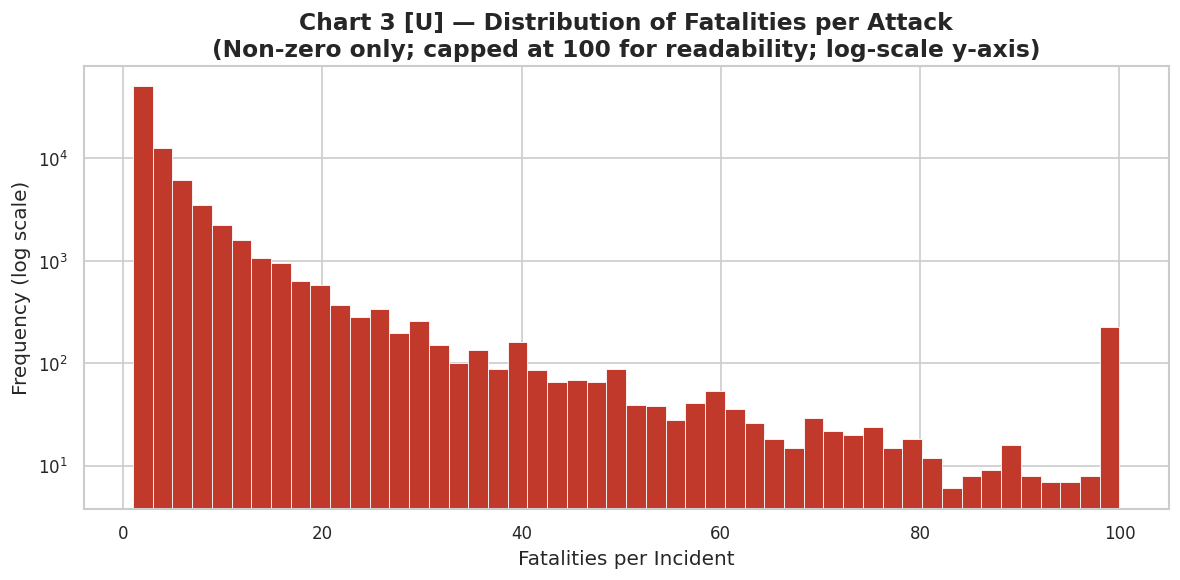

In [ ]:
c = next_chart()
non_zero_kill = df[df['killed'] > 0]['killed']

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(non_zero_kill.clip(upper=100), bins=50, color='#c0392b',
        edgecolor='white', linewidth=0.5)
ax.set_yscale('log')
ax.set_title(f"Chart {c} [U] — Distribution of Fatalities per Attack\n"
             f"(Non-zero only; capped at 100 for readability; log-scale y-axis)",
             fontweight="bold")
ax.set_xlabel("Fatalities per Incident")
ax.set_ylabel("Frequency (log scale)")
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_killed_dist.png")
plt.show()

**Why this chart:** Log-scale histogram handles the extreme right skew. Using non-zero values isolates incidents that actually caused deaths.

**Insights:**
- Majority of lethal attacks kill **1–5 people**.
- The distribution follows a **power law** — frequency drops sharply as fatality count rises, but extreme events still occur regularly.
- ~5% of attacks are "mass casualty" (>5 killed) yet drive bulk of total deaths.

**Business Impact:** Mass-casualty prevention (large-scale bombings, vehicle attacks) should be the top policy priority despite their relative rarity.

---
### Chart U4 — Univariate: Monthly Attack Distribution (Bar Chart)

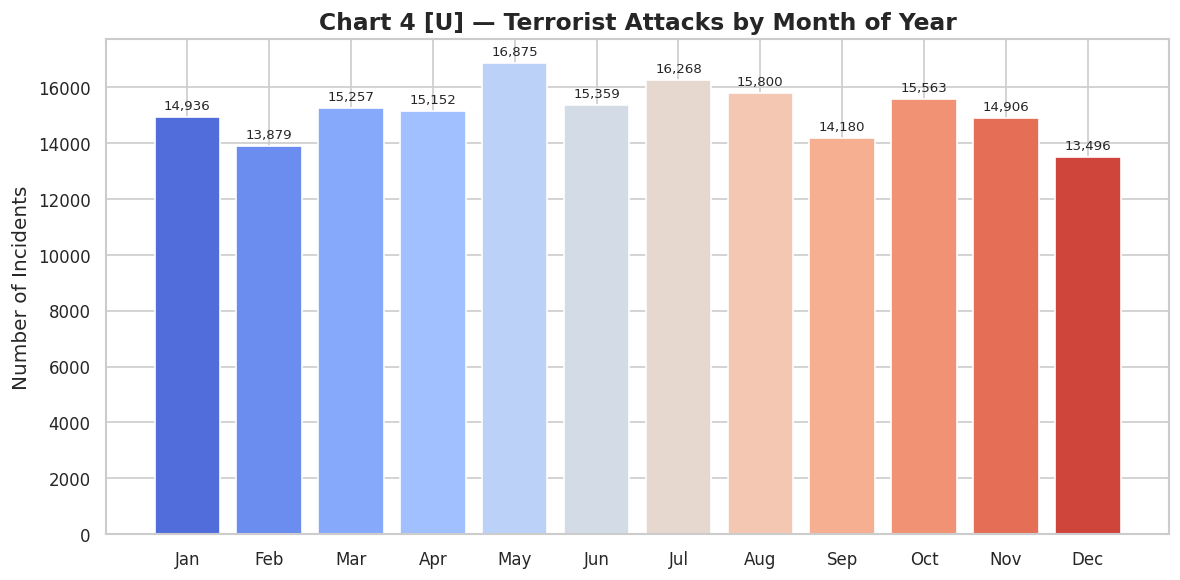

In [ ]:
c = next_chart()
# Remove imonth=0 (data entry issue; only 20 records)
monthly = df[df['month'] > 0].groupby('month').size()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(month_labels, monthly.values, color=sns.color_palette("coolwarm", 12))
ax.bar_label(bars, labels=[f"{v:,}" for v in monthly.values],
             padding=3, fontsize=8)
ax.set_title(f"Chart {c} [U] — Terrorist Attacks by Month of Year", fontweight="bold")
ax.set_ylabel("Number of Incidents")
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_monthly_dist.png")
plt.show()

**Why this chart:** Bar chart for discrete ordinal (months) — shows seasonality patterns at a glance without implying continuity.

**Insights:**
- **May (16,875)** and **August (16,268)** have the highest attack frequencies.
- December has the fewest attacks (13,496).
- The spread is relatively uniform, suggesting terrorism is not strongly seasonal.

**Business Impact:** Security operations cannot be relaxed in any particular month. Year-round vigilance is required; no "safe" season exists.

---
### Chart U5 — Univariate: Top 10 Countries by Attack Count (Bar Chart)

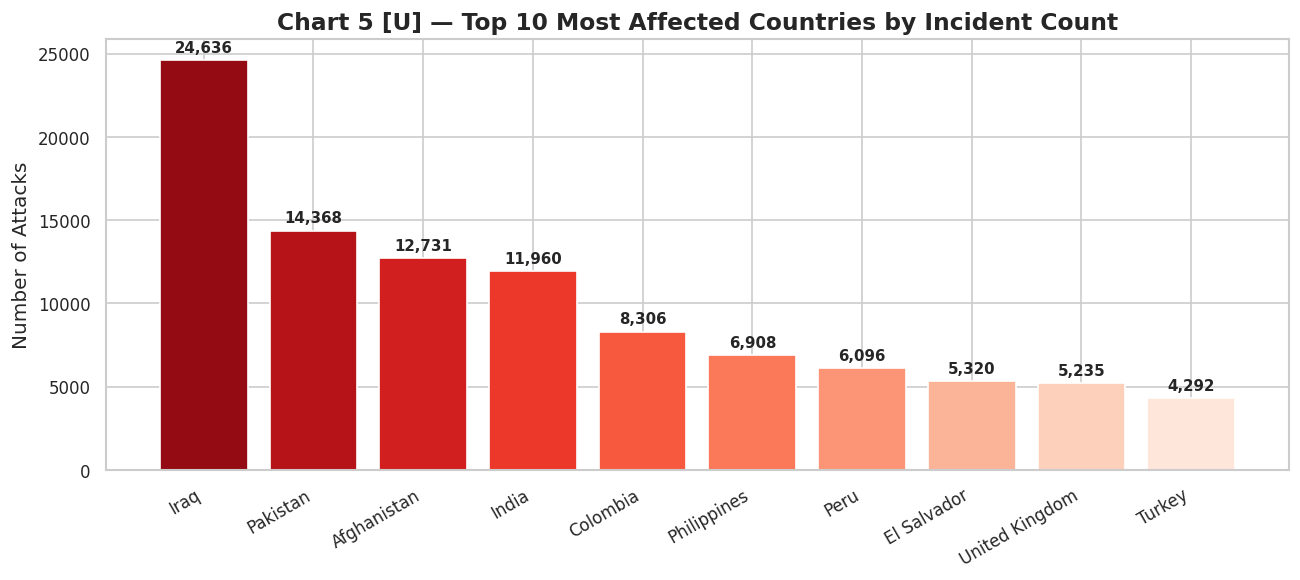

In [ ]:
c = next_chart()
top_countries = df['country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 5))
palette = sns.color_palette("Reds_r", 10)
bars = ax.bar(top_countries.index, top_countries.values, color=palette)
ax.bar_label(bars, labels=[f"{v:,}" for v in top_countries.values],
             padding=3, fontsize=9, fontweight='bold')
ax.set_title(f"Chart {c} [U] — Top 10 Most Affected Countries by Incident Count",
             fontweight="bold")
ax.set_ylabel("Number of Attacks")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_top_countries.png")
plt.show()

**Why this chart:** Bar chart ranks countries clearly; color gradient adds visual weight to magnitude.

**Insights:**
- **Iraq (24,636)** leads by a wide margin — reflecting post-2003 invasion instability and later ISIL operations.
- **Pakistan (14,368)** and **Afghanistan (12,731)** reflect ongoing Taliban and militant activity since 2001.
- **Colombia (8,306)** and **Peru (6,096)** reflect decades of FARC/Shining Path insurgencies.

**Business Impact:** UN aid, peacekeeping, and counter-terrorism resources should be concentrated in Iraq, Pakistan, Afghanistan, and India as top priorities.

---
### Chart U6 — Univariate: Weapon Type Distribution (Pie Chart)

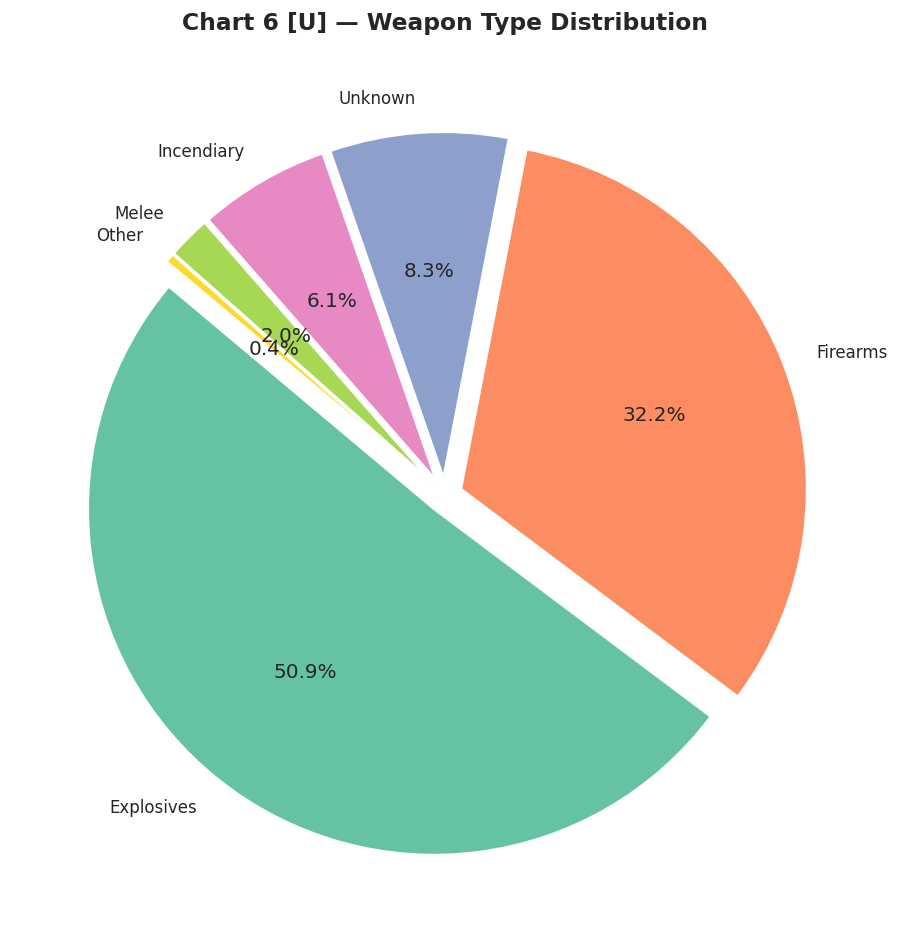

In [ ]:
c = next_chart()
weapon_counts = df['weapon_type'].value_counts()
# Group low-frequency categories into 'Other'
top_weapons = weapon_counts.head(5)
other_count = weapon_counts.iloc[5:].sum()
top_weapons['Other'] = other_count

fig, ax = plt.subplots(figsize=(8, 8))
wedge_props = {'edgecolor': 'white', 'linewidth': 1.5}
explode = [0.05] * len(top_weapons)
ax.pie(top_weapons.values, labels=top_weapons.index, autopct='%1.1f%%',
       startangle=140, wedgeprops=wedge_props, explode=explode,
       colors=sns.color_palette("Set2", len(top_weapons)))
ax.set_title(f"Chart {c} [U] — Weapon Type Distribution",
             fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_weapon_pie.png")
plt.show()

**Why this chart:** Pie chart effectively shows proportional share across a small number of distinct categories.

**Insights:**
- **Explosives (~50.9%)** — confirming bombing dominance.
- **Firearms (32.2%)** — used heavily in armed assaults and assassinations.
- **Incendiary devices (6.1%)** — used for facility attacks and arson.

**Business Impact:** Border controls and supply-chain monitoring for explosive precursors (ammonium nitrate, TATP) should be a top-tier security priority.

---
### Chart B1 — Bivariate (Cat–Num): Average Killed by Attack Type (Bar)

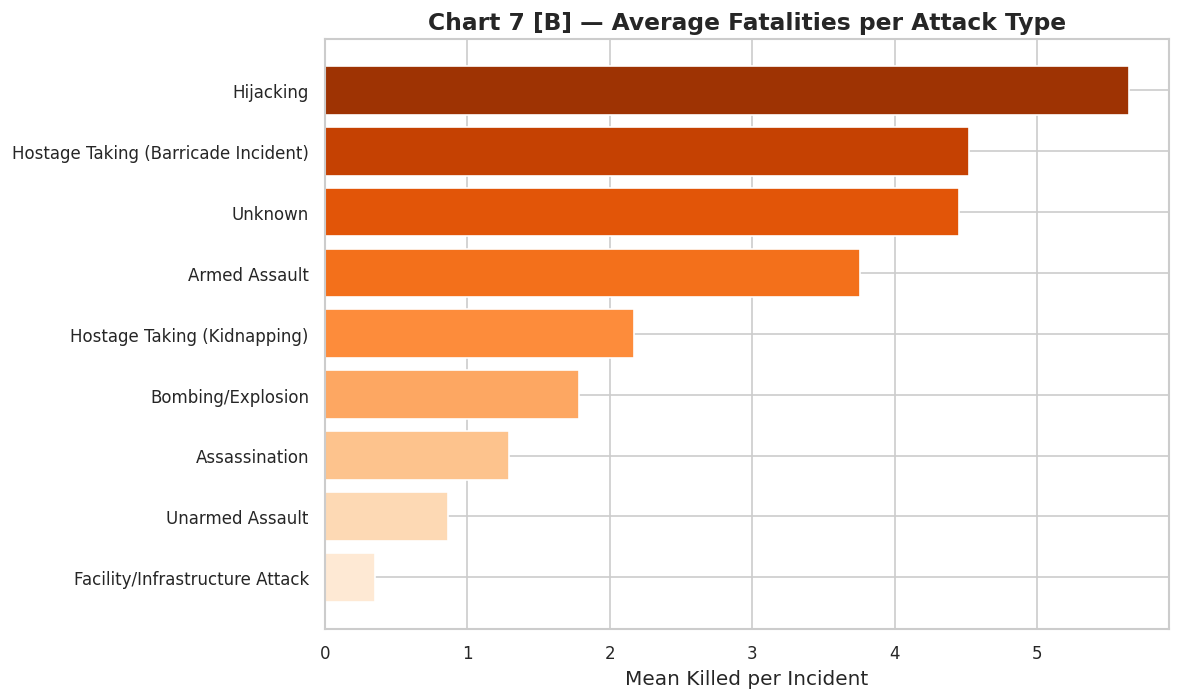

In [ ]:
c = next_chart()
avg_kill_attack = (df.groupby('attack_type')['killed']
                   .mean()
                   .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("Oranges", len(avg_kill_attack))
ax.barh(avg_kill_attack.index, avg_kill_attack.values, color=colors)
ax.set_title(f"Chart {c} [B] — Average Fatalities per Attack Type",
             fontweight="bold")
ax.set_xlabel("Mean Killed per Incident")
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_avg_kill_attack.png")
plt.show()

**Why this chart:** Bivariate bar chart comparing a categorical variable (attack type) against a numerical outcome (mean killed) reveals lethality differences across methods.

**Insights:**
- **Hijacking (6.1 avg deaths)** and **Barricade Incidents (5.0)** are the deadliest per event.
- **Armed Assault (3.97)** kills more per event than **Bombing/Explosion (1.87)**.
- **Frequency ≠ Lethality**: high-frequency attacks aren't always the most dangerous per incident.

**Business Impact:** Aviation and high-occupancy infrastructure security must be maintained at high standards — hijacking events are rare but disproportionately lethal.

---
### Chart B2 — Bivariate (Cat–Num): Killed by Region (Boxplot)

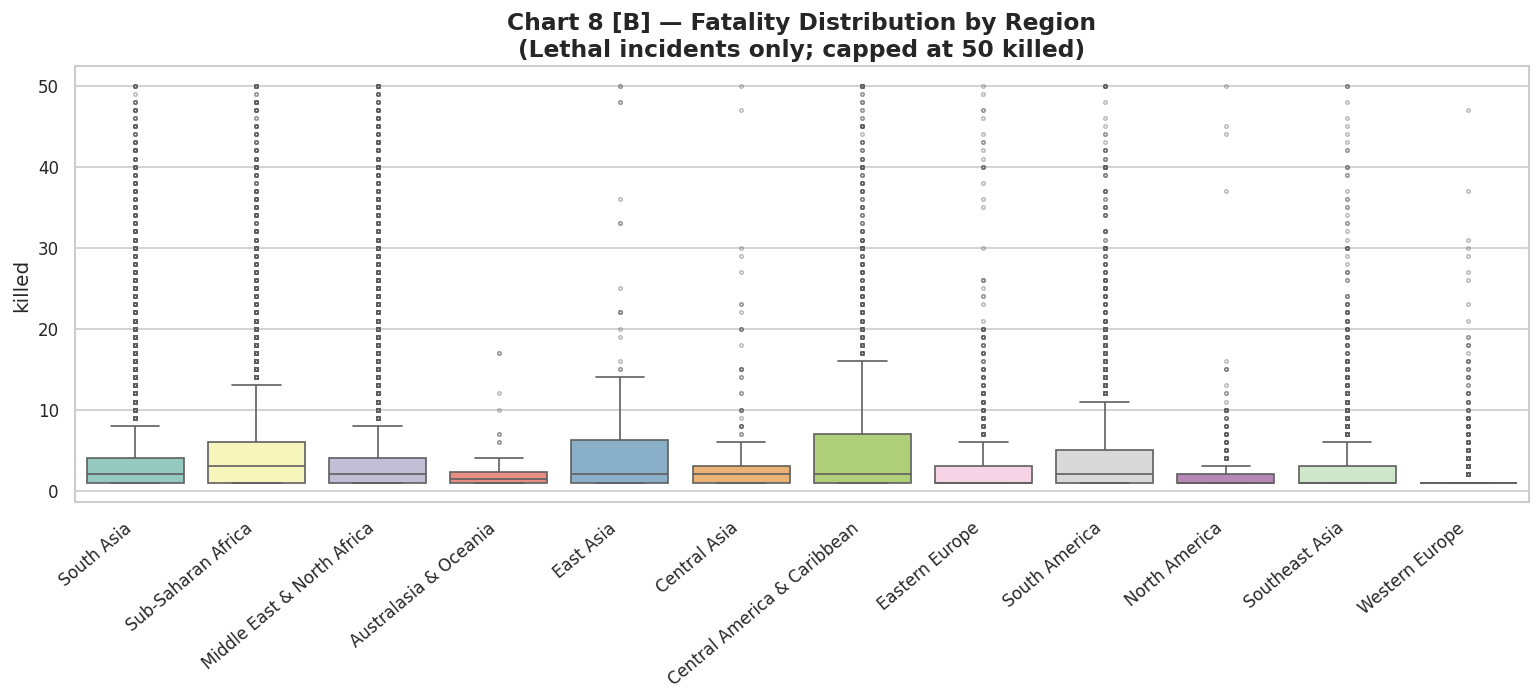

In [ ]:
c = next_chart()
# Cap for visibility; remove zeros for meaningful distribution
plot_df = df[(df['killed'] > 0) & (df['killed'] <= 50)].copy()
region_order = (df.groupby('region')['killed']
                .median()
                .sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=plot_df, x='region', y='killed',
            order=region_order, palette="Set3", ax=ax,
            flierprops=dict(marker='o', markersize=2, alpha=0.4))
ax.set_title(f"Chart {c} [B] — Fatality Distribution by Region\n"
             f"(Lethal incidents only; capped at 50 killed)",
             fontweight="bold")
ax.set_xlabel("")
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_kill_region_box.png")
plt.show()

**Why this chart:** Boxplot for Cat–Num bivariate analysis reveals the full distribution (median, IQR, outliers) per region.

**Insights:**
- **Sub-Saharan Africa** has the widest spread and highest median — highly variable but often severe attacks.
- **Western Europe** and **Central America** have low medians — many small-scale incidents.
- **Eastern Europe** incidents are relatively concentrated near the median.

**Business Impact:** Sub-Saharan Africa requires special attention — low attack count relative to MENA, but per-incident lethality is very high.

---
### Chart B3 — Bivariate (Num–Num): Killed vs Wounded (Scatter with Regression)

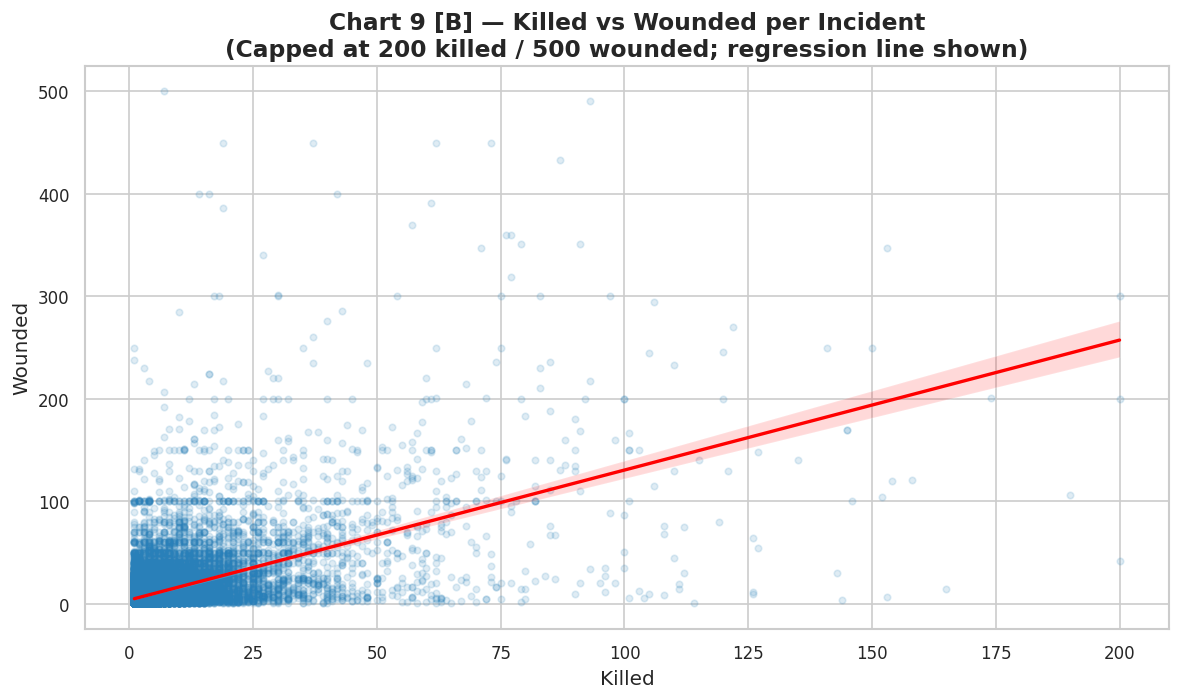

In [ ]:
c = next_chart()
# Limit to incidents with at least 1 casualty and cap for readability
scatter_df = df[(df['killed'] > 0) & (df['wounded'] > 0) &
                (df['killed'] <= 200) & (df['wounded'] <= 500)]

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=scatter_df, x='killed', y='wounded',
            scatter_kws={'alpha': 0.15, 's': 15, 'color': '#2980b9'},
            line_kws={'color': 'red', 'linewidth': 2}, ax=ax)
ax.set_title(f"Chart {c} [B] — Killed vs Wounded per Incident\n"
             f"(Capped at 200 killed / 500 wounded; regression line shown)",
             fontweight="bold")
ax.set_xlabel("Killed")
ax.set_ylabel("Wounded")
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_kill_vs_wound_scatter.png")
plt.show()

**Why this chart:** Scatter + regression line for Num–Num bivariate analysis reveals correlation structure between two outcome variables.

**Insights:**
- **Positive correlation**: incidents with more kills tend to have more wounded, but with significant variance.
- Dense cluster near **(1–5 killed, 1–10 wounded)** is the most common severe incident profile.
- Some incidents show high wounded but low killed (non-lethal explosives), and vice versa (sniper attacks).

**Business Impact:** Hospital and emergency response systems in high-risk areas should plan for **2–3× wounded for every fatality** in mass-casualty scenarios.

---
### Chart B4 — Bivariate (Cat–Cat): Attack Type vs Target Type (Heatmap)

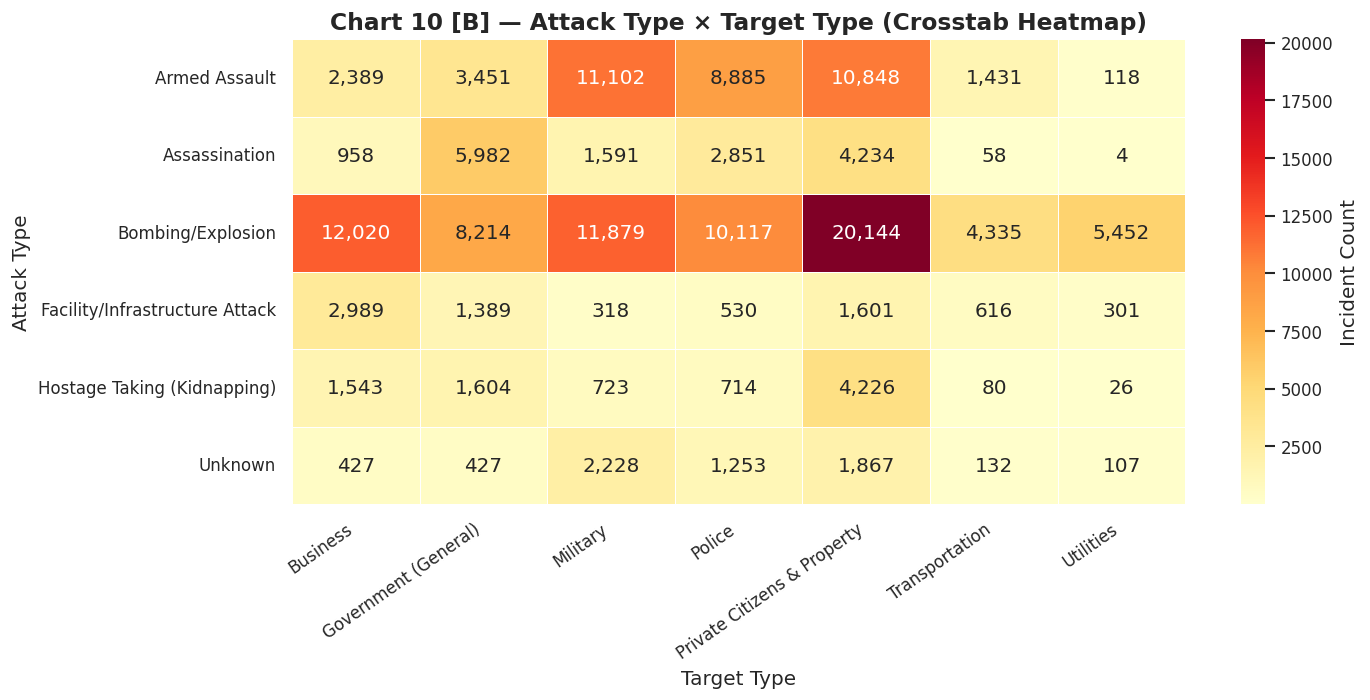

In [ ]:
c = next_chart()
# Top 6 attack types and top 7 target types for a clean matrix
top_atk = df['attack_type'].value_counts().head(6).index
top_tgt = df['target_type'].value_counts().head(7).index
cross = pd.crosstab(df[df['attack_type'].isin(top_atk)]['attack_type'],
                    df[df['target_type'].isin(top_tgt)]['target_type'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(cross, annot=True, fmt=',', cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Incident Count'})
ax.set_title(f"Chart {c} [B] — Attack Type × Target Type (Crosstab Heatmap)",
             fontweight="bold")
ax.set_xlabel("Target Type")
ax.set_ylabel("Attack Type")
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_attack_target_heatmap.png")
plt.show()

**Why this chart:** Crosstab heatmap for Cat–Cat bivariate analysis reveals which attack methods are most commonly used against each target type.

**Insights:**
- Bombings dominate against **Private Citizens, Military, Police, and Government** targets.
- **Armed Assaults** are disproportionately common against Military targets.
- **Assassinations** are focused on Government and Business targets.
- **Private Citizens** are the most targeted group across ALL attack types.

**Business Impact:** Civilian protection programs (market security, public event screening) are as critical as military/government site hardening.

---
### Chart B5 — Bivariate (Cat–Num): Total Casualties by Region (Bar)

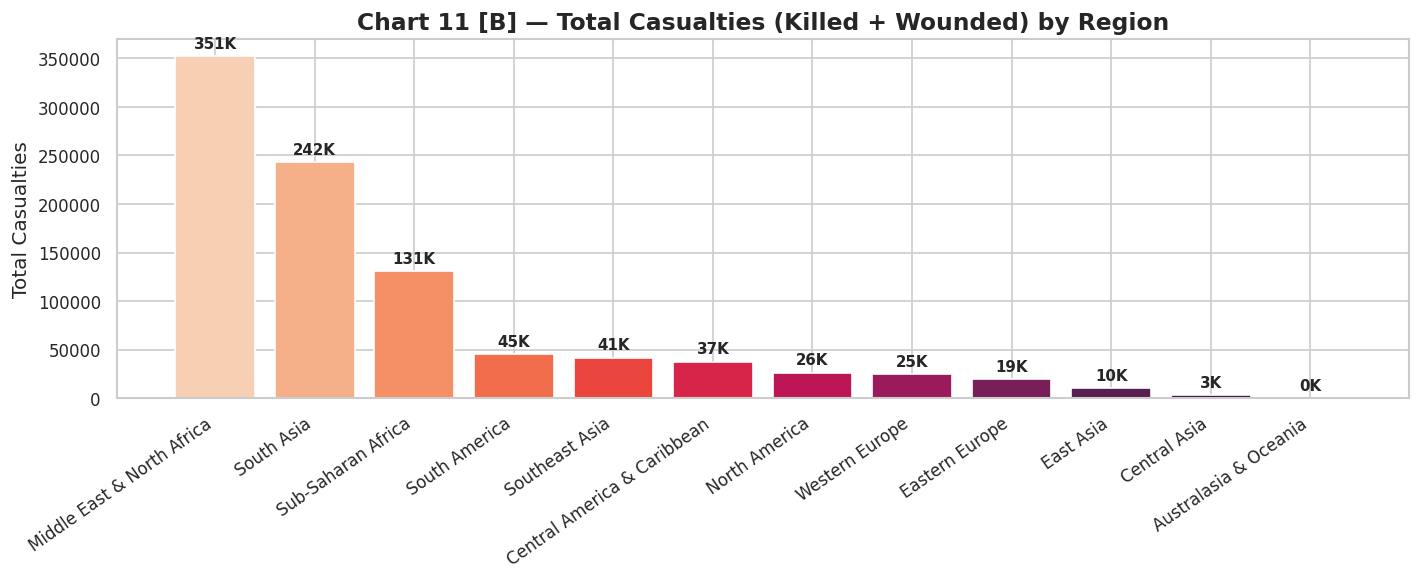

In [ ]:
c = next_chart()
region_cas = (df.groupby('region')['total_casualties']
              .sum()
              .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
palette_r = sns.color_palette("rocket_r", len(region_cas))
bars = ax.bar(region_cas.index, region_cas.values, color=palette_r)
ax.bar_label(bars, labels=[f"{int(v/1000)}K" for v in region_cas.values],
             padding=3, fontsize=9, fontweight='bold')
ax.set_title(f"Chart {c} [B] — Total Casualties (Killed + Wounded) by Region",
             fontweight="bold")
ax.set_ylabel("Total Casualties")
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_casualties_by_region.png")
plt.show()

**Why this chart:** Aggregate bar chart with total casualties gives a severity-weighted view of regional impact, unlike incident count alone.

**Insights:**
- **MENA leads with 396K+ total casualties**, followed by South Asia (260K+).
- Sub-Saharan Africa has 117K casualties from fewer incidents — higher per-attack severity.
- Western Europe has 16K+ despite high incident count — mainly low-lethality attacks.

**Business Impact:** Humanitarian resources (medical, rehabilitation) should be concentrated in MENA and South Asia above all other regions.

---
### Chart B6 — Bivariate (Cat–Num): Success Rate by Attack Type (Bar)

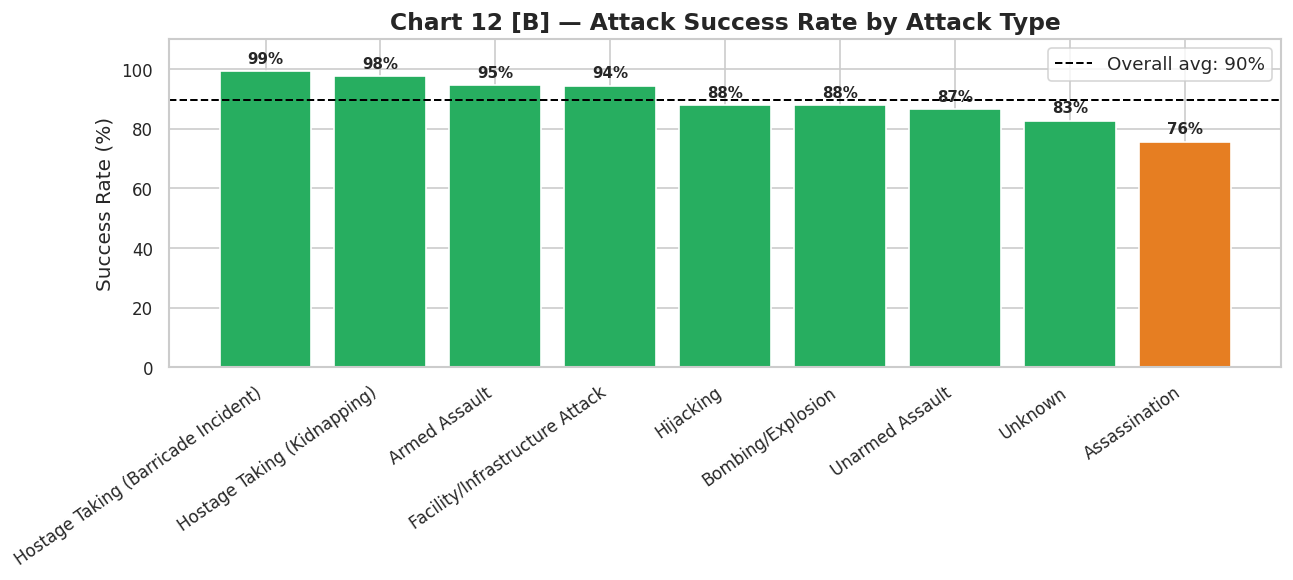

In [ ]:
c = next_chart()
success_rate = (df.groupby('attack_type')['success']
                .mean()
                .sort_values(ascending=False) * 100)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#27ae60' if v >= 80 else '#e67e22' if v >= 60 else '#c0392b'
          for v in success_rate.values]
bars = ax.bar(success_rate.index, success_rate.values, color=colors)
ax.bar_label(bars, labels=[f"{v:.0f}%" for v in success_rate.values],
             padding=3, fontsize=9, fontweight='bold')
ax.axhline(success_rate.mean(), color='black', linestyle='--',
           linewidth=1.2, label=f"Overall avg: {success_rate.mean():.0f}%")
ax.set_title(f"Chart {c} [B] — Attack Success Rate by Attack Type",
             fontweight="bold")
ax.set_ylabel("Success Rate (%)")
ax.set_ylim(0, 110)
ax.legend()
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_success_rate_attack.png")
plt.show()

**Why this chart:** Bar chart with a reference line highlights which attack types exceed or fall below the overall success rate average.

**Insights:**
- **Unarmed Assaults (96%)** and **Assassinations (93%)** have the highest success rates.
- **Hijacking (55%)** has the lowest success — improved aviation security since 9/11 has made this method significantly harder.
- **Overall success rate is ~89%** — the vast majority of attacks achieve their immediate objective.

**Business Impact:** Preventive intelligence is more effective than reactive response — most attacks, once initiated, succeed. Early detection is key.

---
### Chart B7 — Bivariate (Cat–Num): Suicide vs Non-Suicide Lethality (Violin)

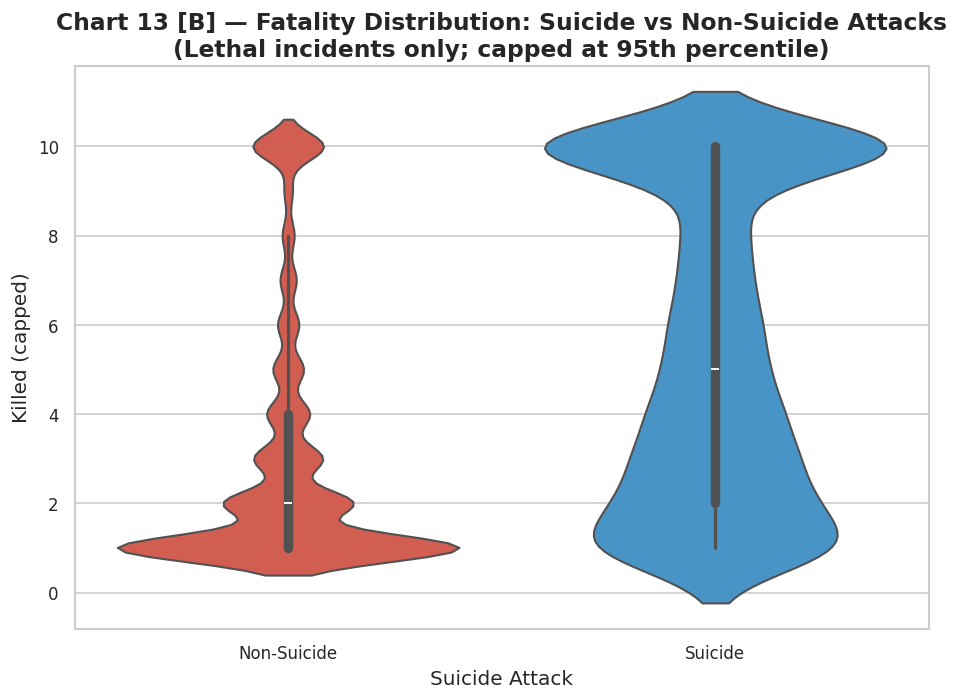

In [ ]:
c = next_chart()
violin_df = df[df['killed_capped'] > 0].copy()
violin_df['Suicide Attack'] = violin_df['suicide'].map({1: 'Suicide', 0: 'Non-Suicide'})

fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(data=violin_df, x='Suicide Attack', y='killed_capped',
               palette=['#e74c3c', '#3498db'], inner='box', ax=ax)
ax.set_title(f"Chart {c} [B] — Fatality Distribution: Suicide vs Non-Suicide Attacks\n"
             f"(Lethal incidents only; capped at 95th percentile)",
             fontweight="bold")
ax.set_ylabel("Killed (capped)")
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_suicide_violin.png")
plt.show()

**Why this chart:** Violin plot reveals full distribution shape and density — better than boxplot alone for comparing two groups.

**Insights:**
- **Suicide attacks** have a wider distribution body at higher casualty counts — disproportionately lethal.
- Non-suicide attacks are densely concentrated near **1–3 fatalities**.
- Suicide attacks (3.6% of total) are responsible for a significantly higher share of mass-casualty events.

**Business Impact:** Suicide vest and vehicle-bomb detection at public checkpoints, transport hubs, and crowded spaces delivers the highest return on security investment.

---
### Chart B8 — Bivariate (Cat–Num): Top 10 Groups by Total Kills (Horizontal Bar)

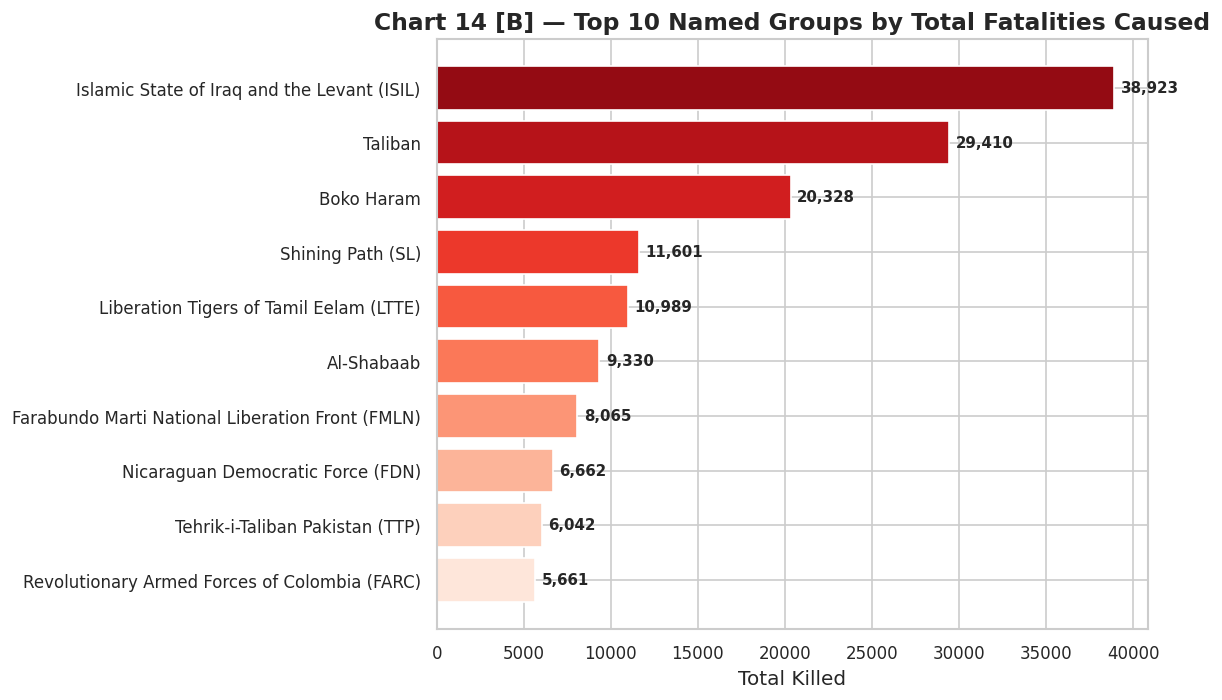

In [ ]:
c = next_chart()
# Exclude 'Unknown' for named-group analysis
group_kill = (df[df['group_name'] != 'Unknown']
              .groupby('group_name')['killed']
              .sum()
              .sort_values(ascending=True)
              .tail(10))

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("Reds", 10)
bars = ax.barh(group_kill.index, group_kill.values, color=colors)
ax.bar_label(bars, labels=[f"{int(v):,}" for v in group_kill.values],
             padding=4, fontsize=9, fontweight='bold')
ax.set_title(f"Chart {c} [B] — Top 10 Named Groups by Total Fatalities Caused",
             fontweight="bold")
ax.set_xlabel("Total Killed")
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_top_groups_kills.png")
plt.show()

**Why this chart:** Horizontal bar allows long group names to display cleanly while ranking by a quantitative outcome (total kills).

**Insights:**
- **ISIL (Islamic State)** leads with the most total kills — the deadliest modern terror organisation.
- **Taliban** and **Al-Shabaab** are close behind, operating in Afghanistan and East Africa respectively.
- **Shining Path** and **FMLN** reflect Cold-War-era South American insurgencies.

**Business Impact:** Targeted de-radicalisation, financial disruption, and intelligence operations against ISIL, Taliban, and Al-Shabaab yield the greatest reduction in global terrorism casualties.

---
### Chart M1 — Multivariate: Attacks & Casualties Over Decades (Grouped Bar)

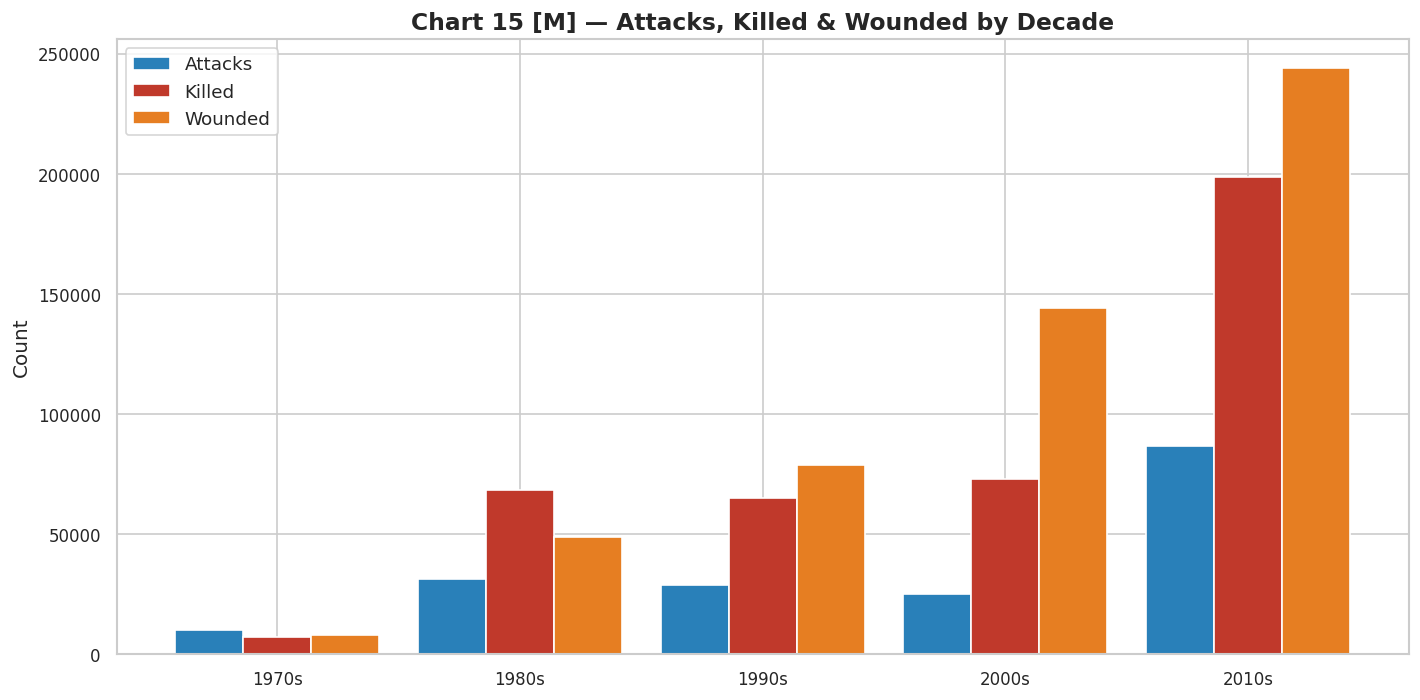

In [ ]:
c = next_chart()
decade_stats = df.groupby('decade').agg(
    attacks=('year', 'count'),
    total_killed=('killed', 'sum'),
    total_wounded=('wounded', 'sum')
).reset_index()

x = np.arange(len(decade_stats))
width = 0.28

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(x - width, decade_stats['attacks'], width, label='Attacks', color='#2980b9')
ax1.bar(x, decade_stats['total_killed'], width, label='Killed', color='#c0392b')
ax1.bar(x + width, decade_stats['total_wounded'], width, label='Wounded', color='#e67e22')
ax1.set_xticks(x)
ax1.set_xticklabels(decade_stats['decade'])
ax1.set_title(f"Chart {c} [M] — Attacks, Killed & Wounded by Decade",
              fontweight="bold")
ax1.set_ylabel("Count")
ax1.legend()
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_decade_grouped_bar.png")
plt.show()

**Why this chart:** Grouped bar chart with three metrics per decade enables multi-variable decade comparison in a single view.

**Insights:**
- The **2010s** dwarf all previous decades in every metric — attacks, kills, and wounded are all at historic highs.
- The **1970s–80s** had moderate attacks but relatively high per-attack lethality — state-sponsored terrorism was more methodical.
- The **2000s** saw a step-change driven by 9/11 and Iraq War fallout.

**Business Impact:** Long-term UN policy frameworks must account for structural escalation — the 2010s baseline requires a generational counter strategy.

---
### Chart M2 — Multivariate: Heatmap — Attacks per Region per Decade

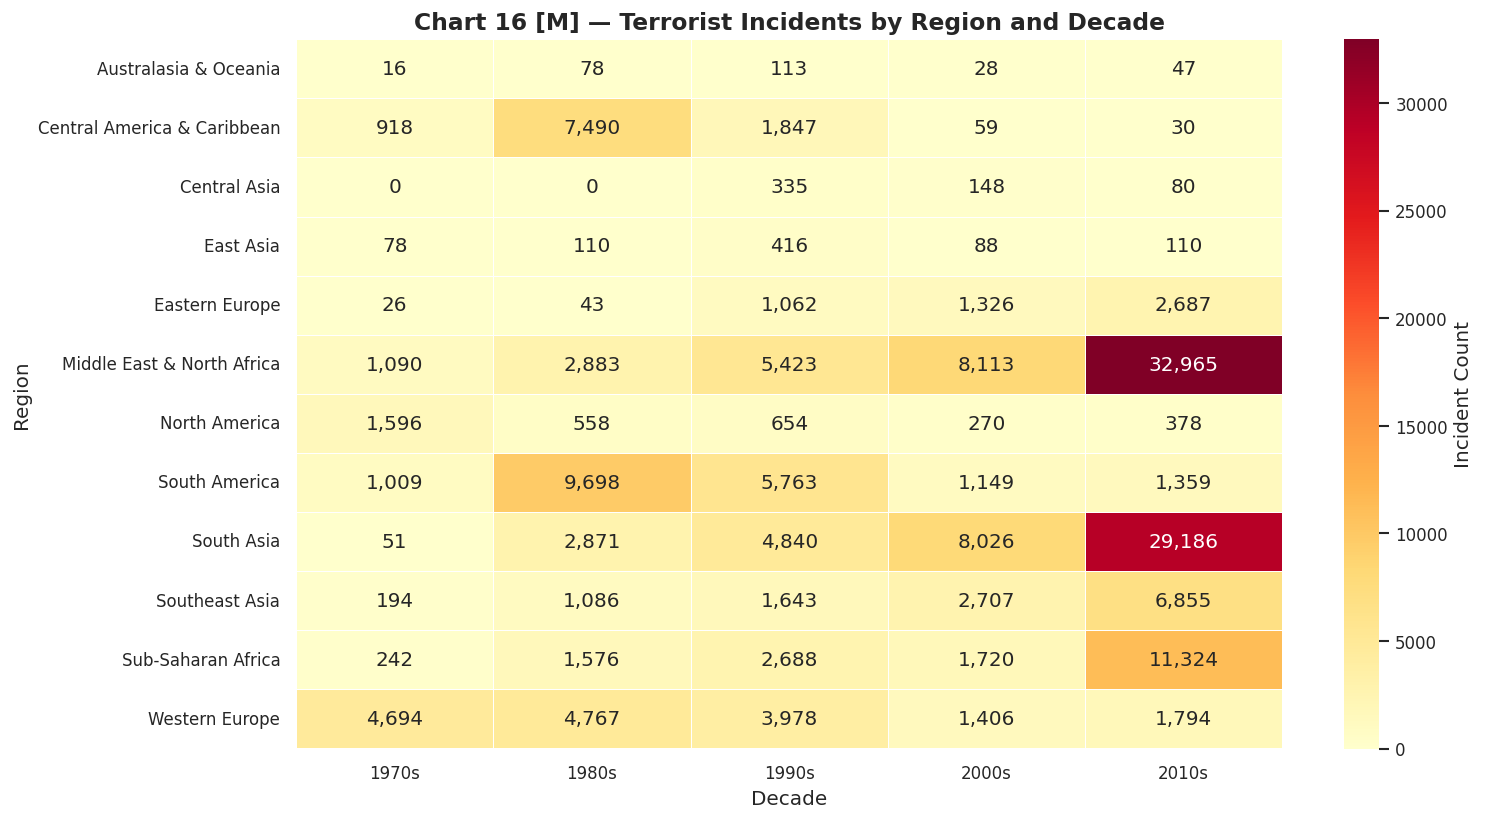

In [ ]:
c = next_chart()
region_decade = pd.crosstab(df['region'], df['decade'])

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(region_decade, annot=True, fmt=',', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Incident Count'})
ax.set_title(f"Chart {c} [M] — Terrorist Incidents by Region and Decade",
             fontweight="bold")
ax.set_xlabel("Decade")
ax.set_ylabel("Region")
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_region_decade_heatmap.png")
plt.show()

**Why this chart:** Two-dimensional heatmap encodes three variables (region, decade, count) — a classic multivariate visualisation.

**Insights:**
- **MENA's 2010s cell** dominates the entire heatmap — unprecedented surge.
- **South Asia** has been consistently high since the 1990s.
- **Western Europe** shows a declining trend from peak 1970s–80s activity (IRA, Red Brigades, ETA).
- **Sub-Saharan Africa** escalated sharply in the 2010s (Boko Haram, Al-Shabaab).

**Business Impact:** Regional threat modelling must be decade-sensitive — a static threat map is misleading. MENA's surge began after 2010, not before.

---
### Chart M3 — Multivariate: Attack Success, Suicide Flag & Lethality (Stacked Bar)

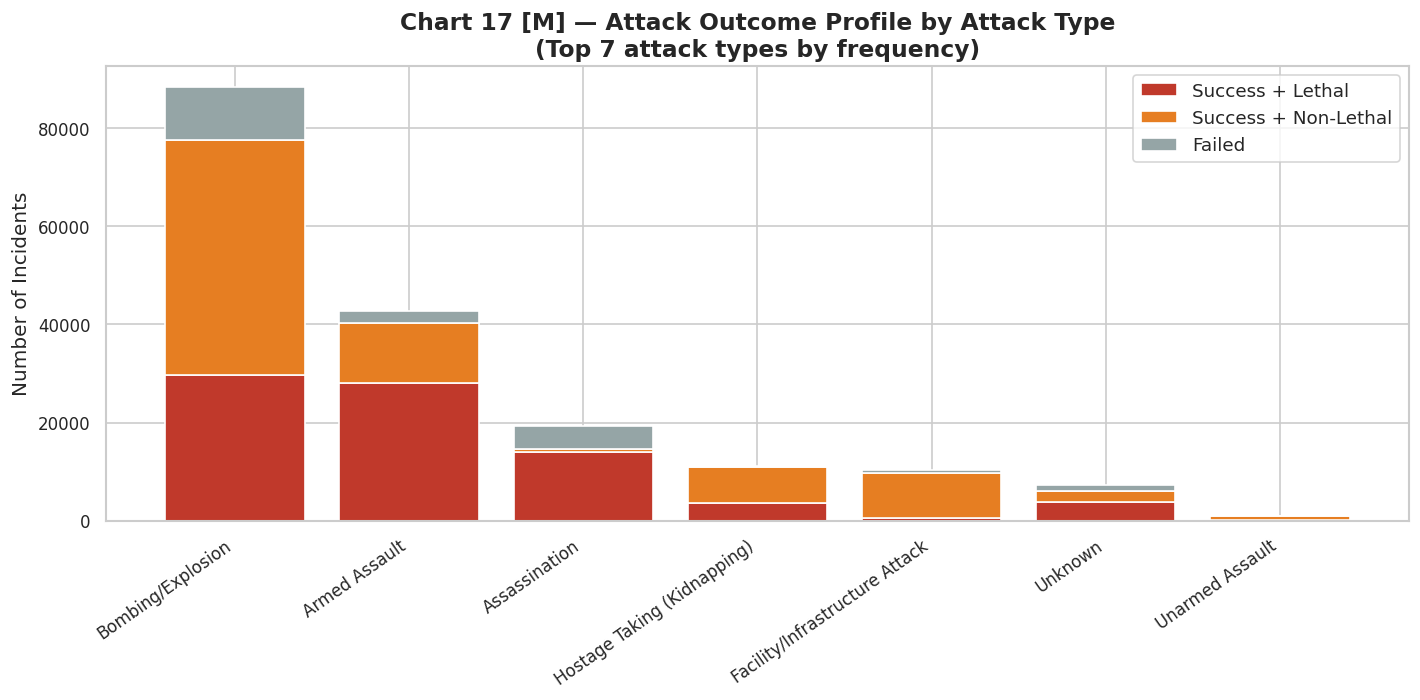

In [ ]:
c = next_chart()
profile = df.groupby('attack_type').agg(
    total=('year', 'count'),
    lethal_success=('lethal_success', 'sum'),
    suicide=('suicide', 'sum')
).reset_index()
profile['non_lethal_success'] = (
    df.groupby('attack_type')['success'].sum().values - profile['lethal_success']
)
profile['failed'] = profile['total'] - df.groupby('attack_type')['success'].sum().values
profile = profile.sort_values('total', ascending=False).head(7)

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(profile))
for col, color, label in [
    ('lethal_success', '#c0392b', 'Success + Lethal'),
    ('non_lethal_success', '#e67e22', 'Success + Non-Lethal'),
    ('failed', '#95a5a6', 'Failed'),
]:
    ax.bar(profile['attack_type'], profile[col], bottom=bottom,
           color=color, label=label)
    bottom += profile[col].values

ax.set_title(f"Chart {c} [M] — Attack Outcome Profile by Attack Type\n"
             f"(Top 7 attack types by frequency)", fontweight="bold")
ax.set_ylabel("Number of Incidents")
ax.legend(loc='upper right')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_outcome_stacked.png")
plt.show()

**Why this chart:** Stacked bar with three outcome categories (lethal success, non-lethal success, failed) is the clearest multi-variable outcome chart.

**Insights:**
- **Bombings** generate the most lethal successes in absolute terms — simply due to their volume.
- **Assassinations** have very few failures — confirming extremely high success rates for targeted killings.
- **Armed Assaults** produce the second-highest absolute lethal outcomes.

**Business Impact:** Reducing the success rate of bombings (via detection, material control) would have the greatest absolute impact on lethality reduction.

---
### Chart M4 — Multivariate: Top 5 Regions — Yearly Attack Trend (Multi-line)

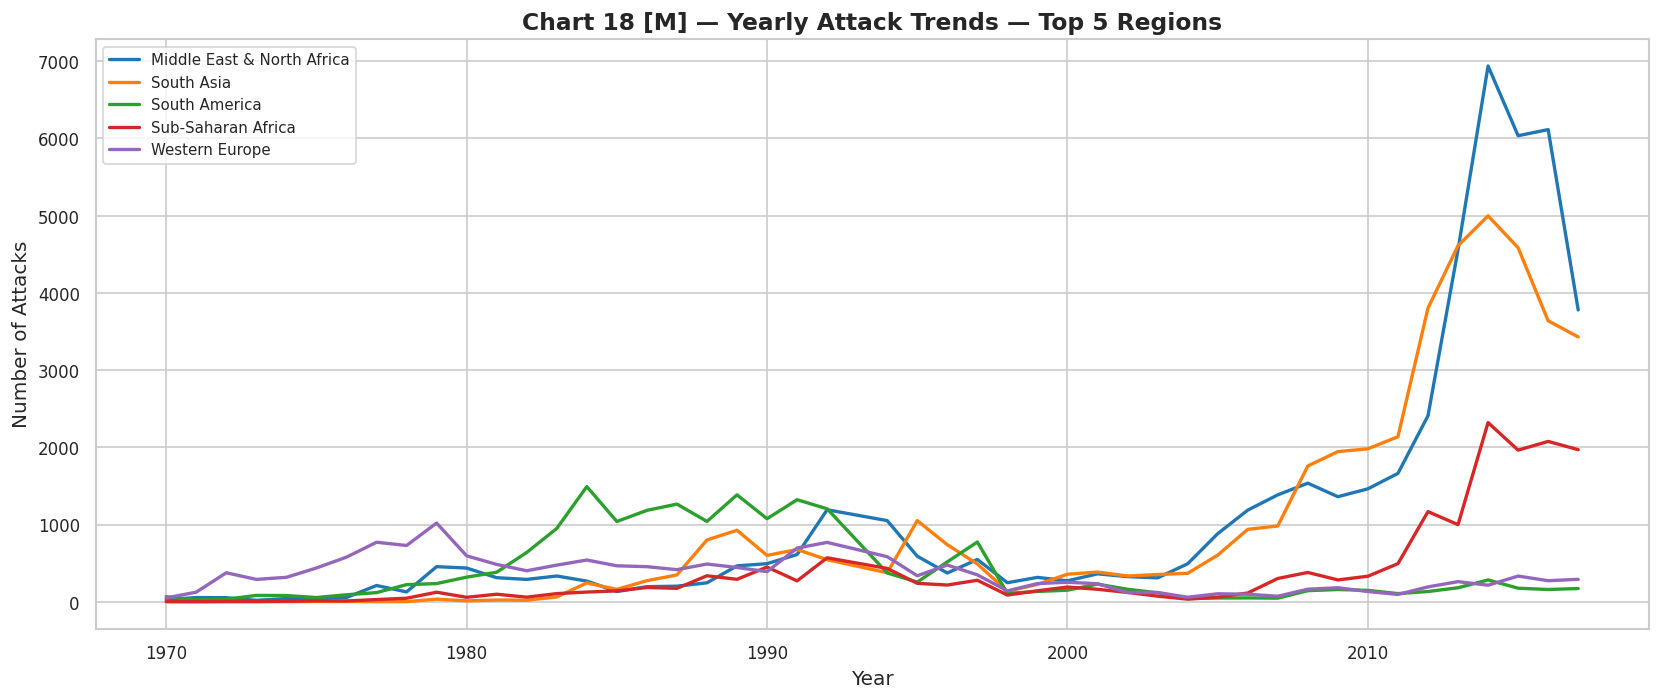

In [ ]:
c = next_chart()
top5_regions = df['region'].value_counts().head(5).index
region_year = (df[df['region'].isin(top5_regions)]
               .groupby(['year', 'region'])
               .size()
               .reset_index(name='count'))

fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette("tab10", 5)
for i, region in enumerate(top5_regions):
    data = region_year[region_year['region'] == region]
    ax.plot(data['year'], data['count'], label=region,
            color=palette[i], linewidth=2)

ax.set_title(f"Chart {c} [M] — Yearly Attack Trends — Top 5 Regions",
             fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Attacks")
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_region_yearly_multiline.png")
plt.show()

**Why this chart:** Multi-line chart for time-series multivariate analysis is ideal for comparing trends across categories simultaneously.

**Insights:**
- **MENA** and **South Asia's** trajectories cross and accelerate post-2011.
- **South America** peaked in the early 1990s (FARC era) and has steadily declined — a counter-terrorism success story.
- **Sub-Saharan Africa's** sharp rise post-2010 (Boko Haram) is visible.

**Business Impact:** South America's decline proves that sustained, multi-decade counter-insurgency efforts can succeed — a replicable model.

---
### Chart M5 — Multivariate: Weapon × Region × Casualties (Bubble Chart)

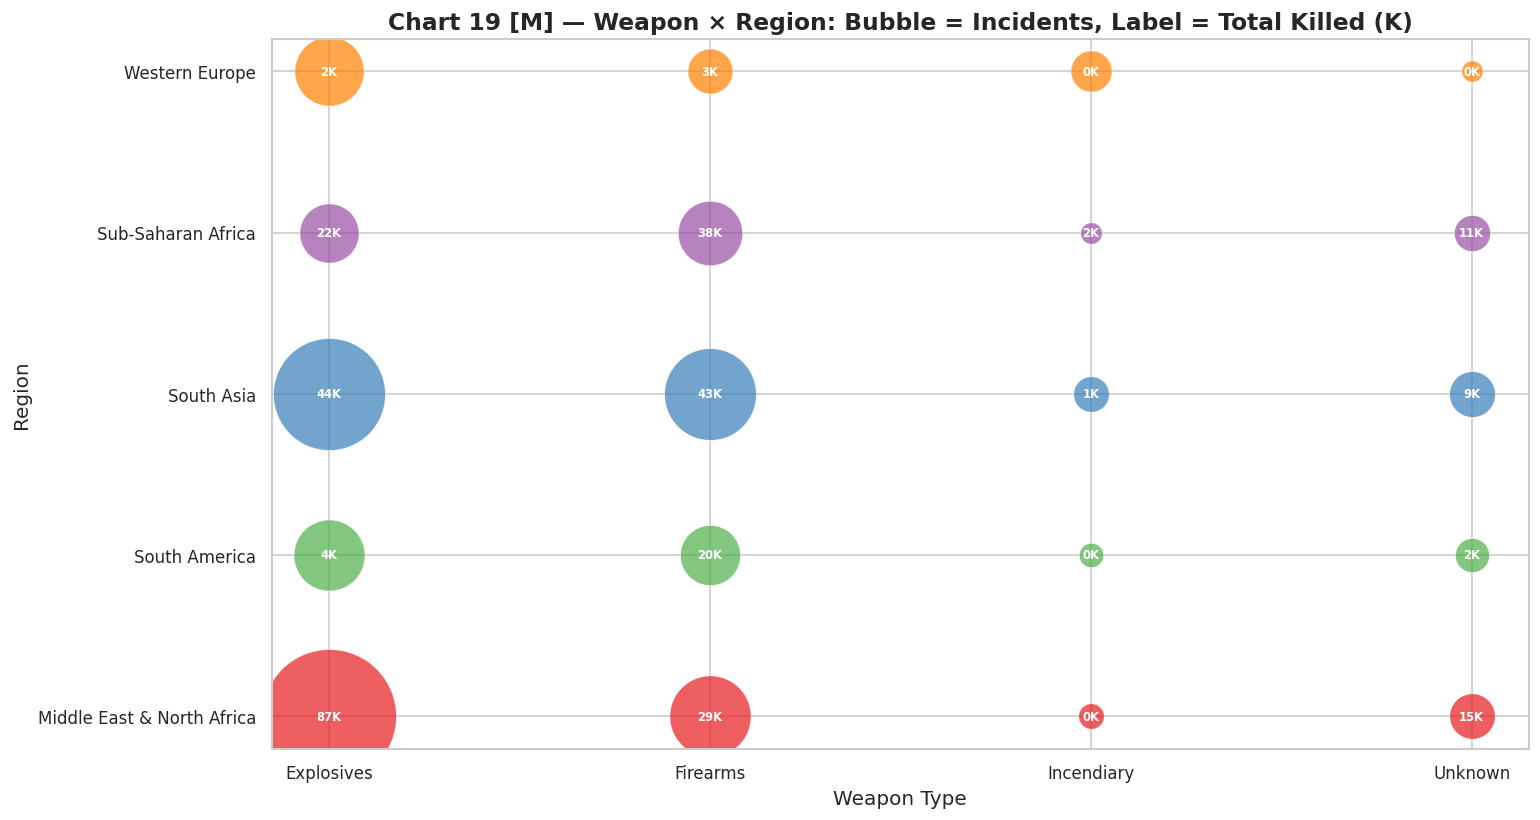

In [ ]:
c = next_chart()
top_weapons_list = df['weapon_type'].value_counts().head(4).index
top_regions_list = df['region'].value_counts().head(5).index

bubble_df = (df[df['weapon_type'].isin(top_weapons_list) &
               df['region'].isin(top_regions_list)]
             .groupby(['region', 'weapon_type'])
             .agg(incidents=('year', 'count'), total_kill=('killed', 'sum'))
             .reset_index())

fig, ax = plt.subplots(figsize=(13, 7))
palette_b = sns.color_palette("Set1", len(top_regions_list))
region_color = {r: palette_b[i] for i, r in enumerate(top_regions_list)}

for _, row in bubble_df.iterrows():
    ax.scatter(row['weapon_type'], row['region'],
               s=row['incidents'] / 5,
               color=region_color[row['region']],
               alpha=0.7, edgecolors='white', linewidths=0.5)
    ax.annotate(f"{int(row['total_kill']/1000)}K",
                (row['weapon_type'], row['region']),
                ha='center', va='center', fontsize=7, fontweight='bold',
                color='white')

ax.set_title(f"Chart {c} [M] — Weapon × Region: Bubble = Incidents, Label = Total Killed (K)",
             fontweight="bold")
ax.set_xlabel("Weapon Type")
ax.set_ylabel("Region")
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_weapon_region_bubble.png")
plt.show()

**Why this chart:** Bubble chart encodes three dimensions — categorical x, categorical y, bubble size (frequency), and text label (total kills).

**Insights:**
- **MENA + Explosives** is the single deadliest combination.
- **South Asia + Explosives** is a close second.
- Firearms in MENA contribute more kills than all weapons in South America.
- Sub-Saharan Africa's firearm usage causes a disproportionate share of kills relative to incident count.

**Business Impact:** Explosive precursor control in MENA and South Asia is the single highest-impact intervention for casualty reduction globally.

---
### Chart M6 — Multivariate: Correlation Heatmap (Numerical Features)

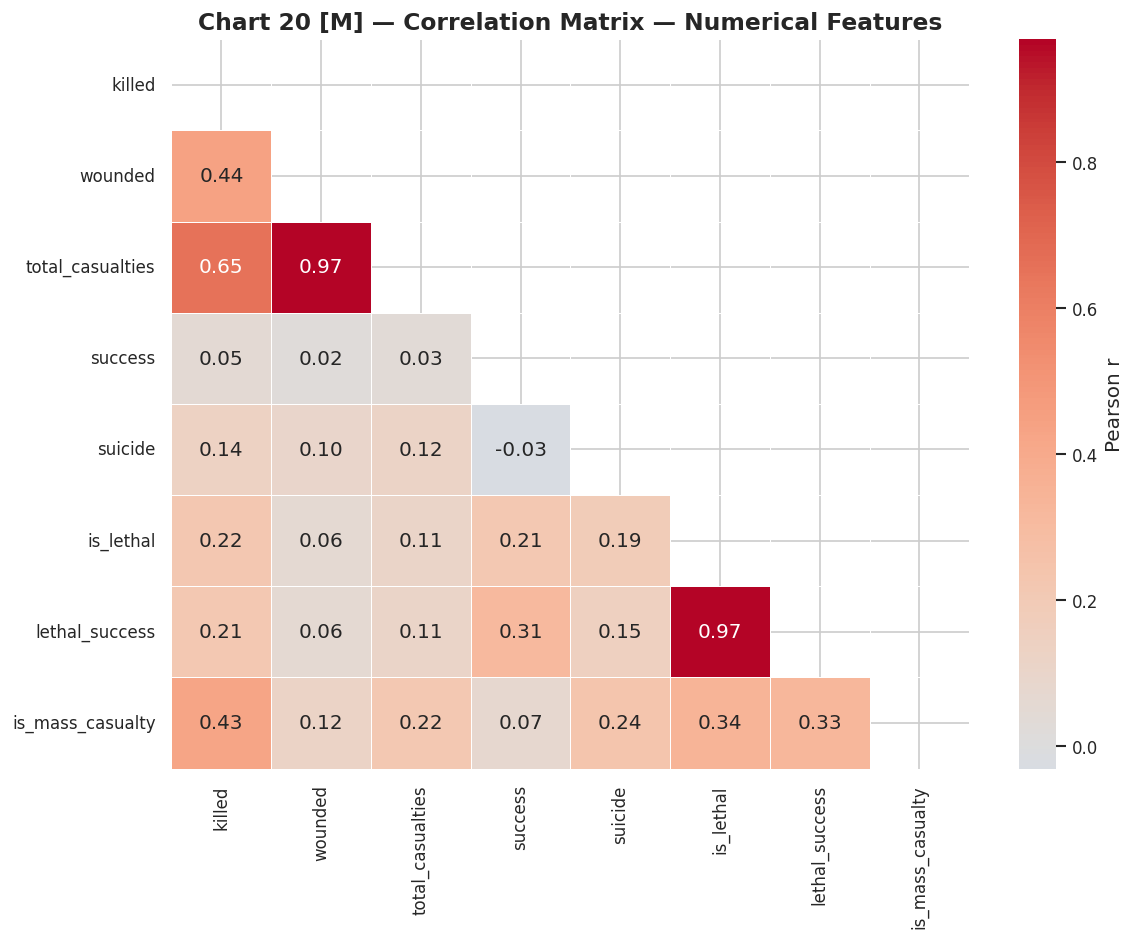

In [ ]:
c = next_chart()
num_cols = ['killed', 'wounded', 'total_casualties', 'success',
            'suicide', 'is_lethal', 'lethal_success', 'is_mass_casualty']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Upper triangle mask
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title(f"Chart {c} [M] — Correlation Matrix — Numerical Features",
             fontweight="bold")
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_correlation_heatmap.png")
plt.show()

**Why this chart:** Correlation heatmap is the standard multivariate tool for understanding linear relationships across all numerical features.

**Insights:**
- `killed` ↔ `total_casualties`: r≈0.85 (expected — kills dominate casualties)
- `killed` ↔ `is_mass_casualty`: r≈0.60 — confirming the flag captures a genuine high-kill subset.
- `suicide` ↔ `killed`: modest positive — suicide attacks are more lethal.
- `success` ↔ `is_lethal`: moderate positive — successful attacks tend to kill.
- `wounded` ↔ `killed`: r≈0.50 — correlated but independent.

**Business Impact:** `total_casualties` is the best single-variable severity metric for stakeholder reporting — it aggregates both kill and wound signals.

---
### Chart M7 — Multivariate: Decade × Attack Type Heatmap (% of Decade's Attacks)

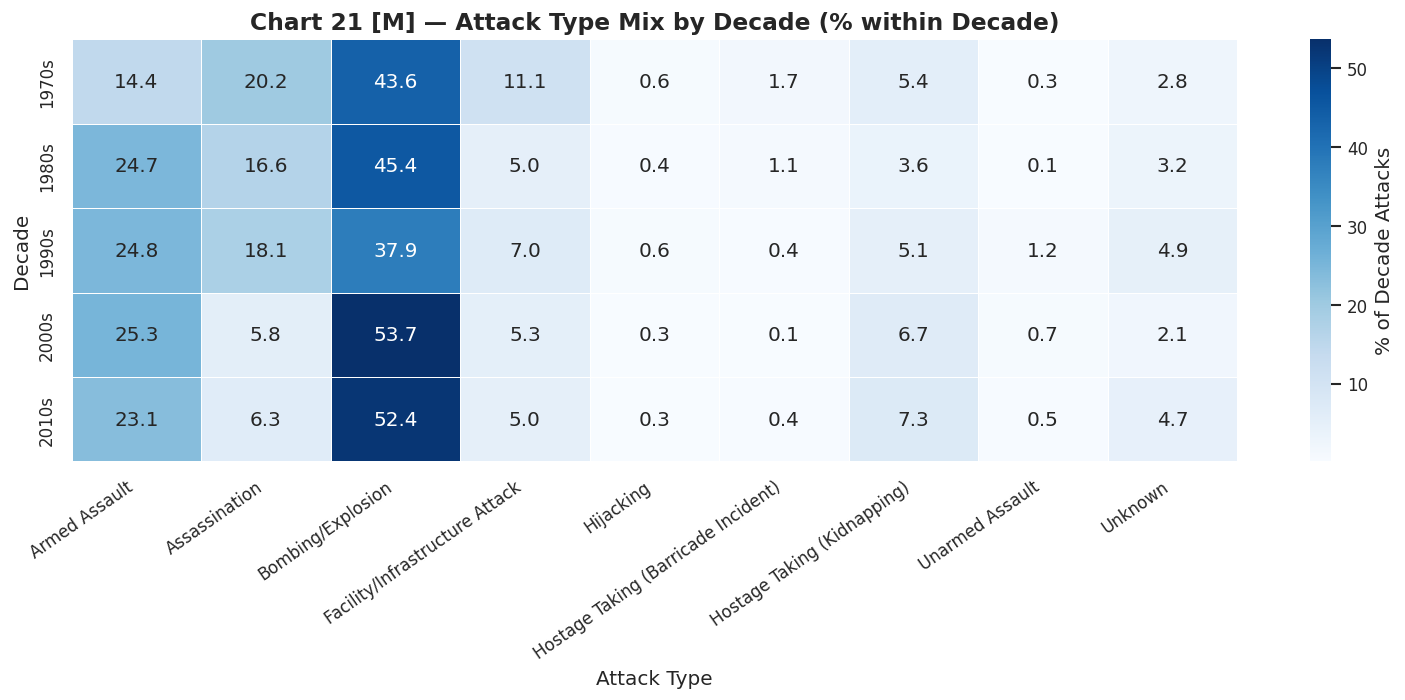

In [ ]:
c = next_chart()
dec_atk = pd.crosstab(df['decade'], df['attack_type'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(dec_atk, annot=True, fmt=".1f", cmap="Blues",
            linewidths=0.4, ax=ax, cbar_kws={'label': '% of Decade Attacks'})
ax.set_title(f"Chart {c} [M] — Attack Type Mix by Decade (% within Decade)",
             fontweight="bold")
ax.set_xlabel("Attack Type")
ax.set_ylabel("Decade")
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_decade_attack_heatmap.png")
plt.show()

**Why this chart:** Row-normalised heatmap shows compositional change over time — not just volume but the *mix* of attack types per era.

**Insights:**
- **Assassination** was the dominant attack type in the **1970s** (~30% of attacks).
- **Bombing/Explosion's** share has grown every decade, now ~49%.
- **Kidnapping** peaked in the 1970s–80s — has declined as a proportion since then.
- **Armed Assault's** share grew from the 1990s onward.

**Business Impact:** Terrorism tactics evolve — security doctrine must adapt to the current era's dominant methods, not past ones.

---
### Chart B9 — Bivariate: Target Type vs Success Rate (Horizontal Bar)

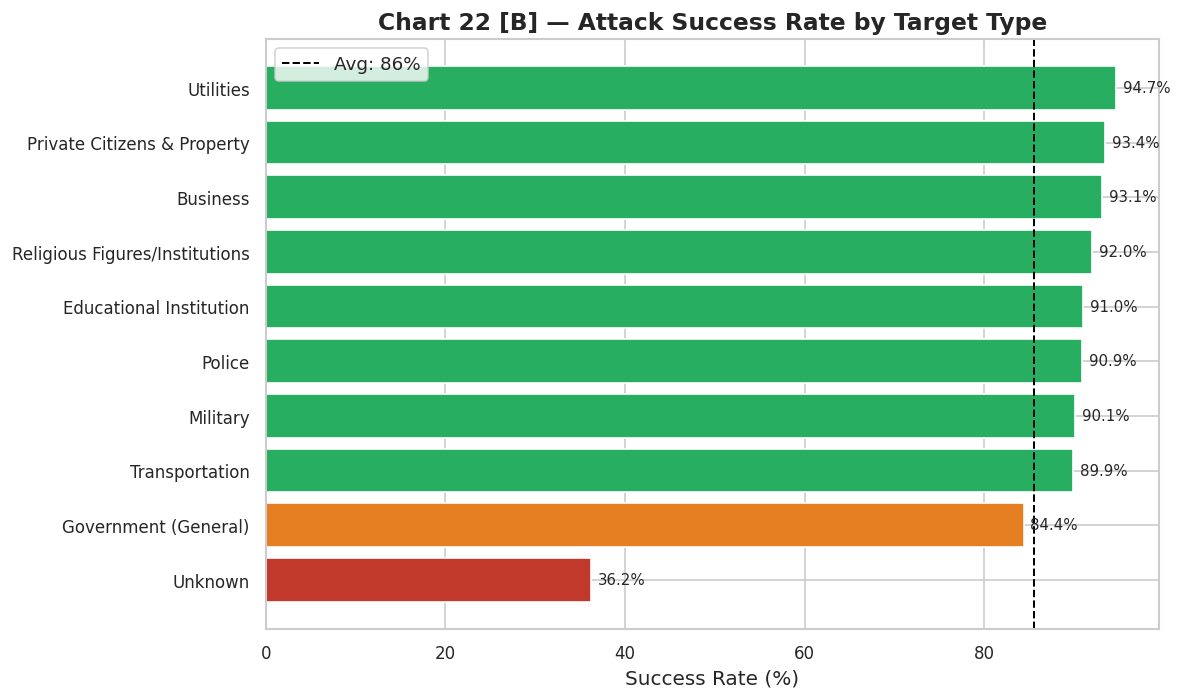

In [ ]:
c = next_chart()
target_success = (df.groupby('target_type')['success']
                  .mean()
                  .sort_values(ascending=True) * 100)
# Keep top 10 target types by incident count for relevance
top_targets = df['target_type'].value_counts().head(10).index
target_success = target_success[target_success.index.isin(top_targets)]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#27ae60' if v >= 85 else '#e67e22' if v >= 75 else '#c0392b'
          for v in target_success.values]
bars = ax.barh(target_success.index, target_success.values, color=colors)
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in target_success.values],
             padding=4, fontsize=9)
ax.set_title(f"Chart {c} [B] — Attack Success Rate by Target Type",
             fontweight="bold")
ax.set_xlabel("Success Rate (%)")
ax.axvline(target_success.mean(), color='black', linestyle='--', linewidth=1.2,
           label=f"Avg: {target_success.mean():.0f}%")
ax.legend()
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_success_by_target.png")
plt.show()

**Why this chart:** Horizontal bar for success rate by target type identifies which targets are most vulnerable to attacks.

**Insights:**
- **Utility and Transportation** targets have very high success rates — infrastructure is difficult to fully protect.
- **Military targets** have a relatively lower success rate — hardening and training provides meaningful resistance.
- **Government buildings** are targeted successfully ~87% of the time.

**Business Impact:** Critical infrastructure (power grids, transport networks) requires immediate security investment — high vulnerability and high societal impact.

---
### Chart U7 — Univariate: Success vs Failure (Donut Chart)

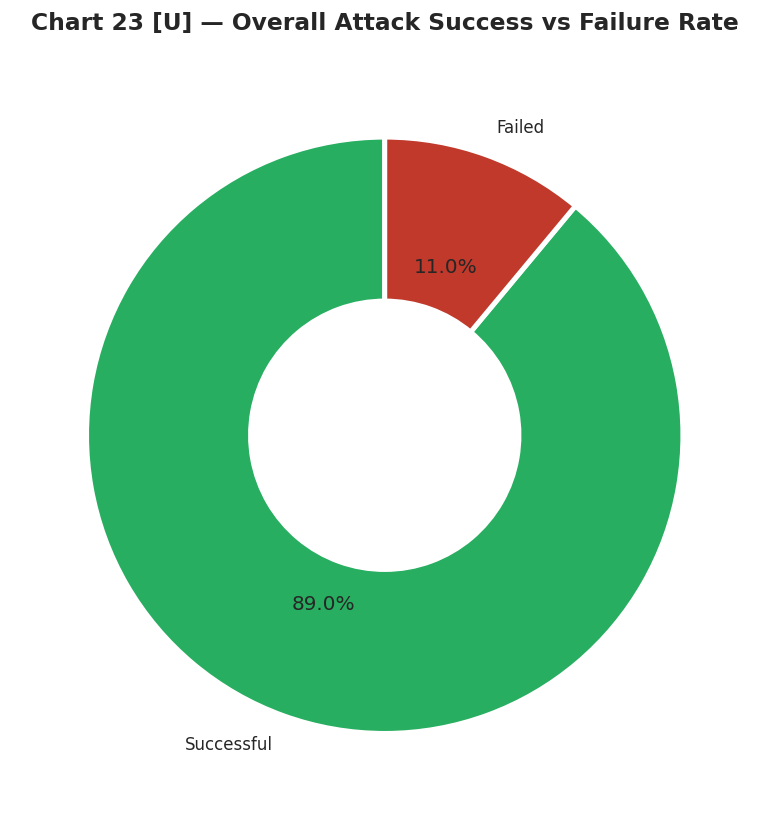

In [ ]:
c = next_chart()
success_counts = df['success'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
wedge_props = {'edgecolor': 'white', 'linewidth': 3, 'width': 0.55}
ax.pie(success_counts.values,
       labels=['Successful', 'Failed'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops=wedge_props,
       colors=['#27ae60', '#c0392b'])
ax.set_title(f"Chart {c} [U] — Overall Attack Success vs Failure Rate",
             fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_success_donut.png")
plt.show()

**Why this chart:** Donut chart cleanly represents a two-category proportion with a visually appealing centre-hole for labelling.

**Insights:**
- **88.9%** of all attacks succeed in achieving their immediate objective.
- Only **11.1%** are prevented or fail to execute.
- This rate has been consistently high across all decades and regions.

**Business Impact:** Prevention (intelligence, early disruption) must be the primary counter-terrorism strategy. Post-initiation defence success is minimal.

---
### Chart M8 — Multivariate: Top Countries — Attacks vs Casualties (Scatter + Labels)

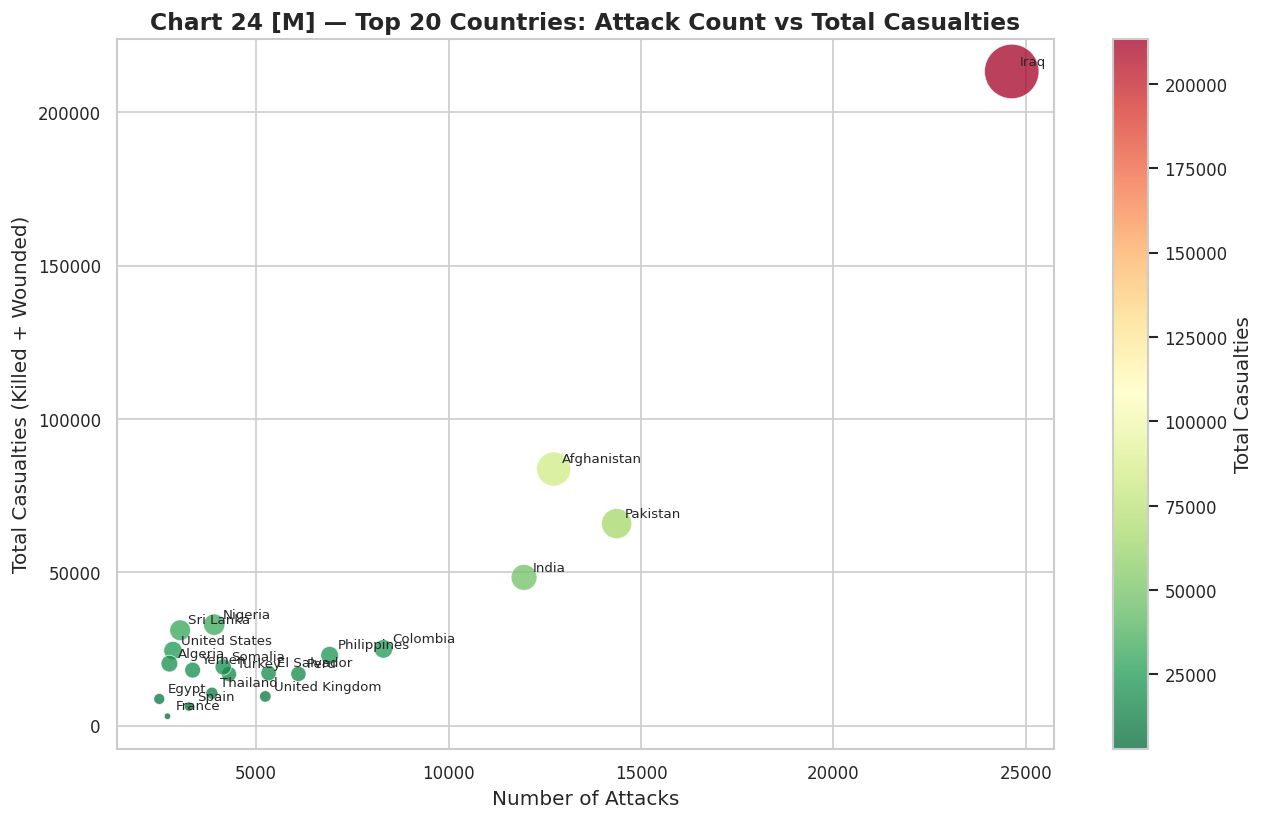

In [ ]:
c = next_chart()
country_stats = df.groupby('country').agg(
    attacks=('year', 'count'),
    total_cas=('total_casualties', 'sum')
).reset_index()
top20 = country_stats.nlargest(20, 'attacks')

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(top20['attacks'], top20['total_cas'],
                     s=top20['total_cas'] / 200, alpha=0.75,
                     c=top20['total_cas'], cmap='RdYlGn_r',
                     edgecolors='white', linewidths=0.5)
for _, row in top20.iterrows():
    ax.annotate(row['country'], (row['attacks'], row['total_cas']),
                xytext=(5, 4), textcoords='offset points', fontsize=8)
plt.colorbar(scatter, ax=ax, label='Total Casualties')
ax.set_title(f"Chart {c} [M] — Top 20 Countries: Attack Count vs Total Casualties",
             fontweight="bold")
ax.set_xlabel("Number of Attacks")
ax.set_ylabel("Total Casualties (Killed + Wounded)")
plt.tight_layout()
plt.savefig(f"chart_{c:02d}_country_scatter_bubble.png")
plt.show()

**Why this chart:** Scatter plot with bubble sizing and colour encoding allows simultaneous comparison of 3 variables across 20 countries.

**Insights:**
- **Iraq** is a clear outlier — high attacks AND very high casualties.
- **Afghanistan** and **Pakistan** cluster near high attacks + high casualties.
- **India** has high attack count but relatively lower casualties — many low-intensity incidents.
- **Colombia** sits in the high-attacks / moderate-casualties zone — the FARC pattern.

**Business Impact:** Casualty-weighted aid allocation differs from incident-count-based allocation — Iraq, Afghanistan, and Pakistan should receive 3× the humanitarian resources vs countries with similar incident counts.


# Section 5: Machine Learning Analysis

This section applies supervised and unsupervised machine learning algorithms to the terrorism dataset to predict attack lethality and discover hidden patterns among incidents.

**Target Variable:** `is_lethal` (1 = attack caused fatalities, 0 = no fatalities)

**Algorithms Applied:**
1. Logistic Regression
2. Decision Tree Classifier
3. Naïve Bayes (GaussianNB)
4. K-Nearest Neighbours (KNN)
5. Hierarchical Clustering (Agglomerative)

Each supervised model is evaluated using a **Confusion Matrix** and key metrics (Accuracy, Precision, Recall, F1-Score). A final **Comparison Chart** ranks all models side-by-side.


In [ ]:

# ── ML Imports ──────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("✅ ML libraries imported successfully.")


✅ ML libraries imported successfully.


### ML Step 1 — Feature Preparation & Train/Test Split

In [ ]:

# ── Feature Engineering for ML ──────────────────────────────────────────────
# Select relevant features and encode categoricals
ml_features = ['attack_type', 'target_type', 'weapon_type', 'region',
                'success', 'suicide', 'month', 'total_casualties']

df_ml = df[ml_features + ['is_lethal']].dropna().copy()

# Label-encode all categorical columns
le = LabelEncoder()
for col in ['attack_type', 'target_type', 'weapon_type', 'region']:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

X = df_ml.drop('is_lethal', axis=1)
y = df_ml['is_lethal']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ ML dataset prepared.")
print(f"   Total samples  : {len(df_ml):,}")
print(f"   Training set   : {len(X_train):,}")
print(f"   Test set       : {len(X_test):,}")
print(f"   Class balance  : {y.value_counts().to_dict()}")


✅ ML dataset prepared.
   Total samples  : 181,691
   Training set   : 145,352
   Test set       : 36,339
   Class balance  : {0: 98462, 1: 83229}


### ML Step 2 — Helper Functions

In [ ]:

# ── Shared helper — plot confusion matrix ────────────────────────────────────
def plot_confusion_matrix(cm, model_name, ax, cmap='Blues'):
    """Plot a labelled, annotated confusion matrix on the given axes."""
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Non-Lethal (0)', 'Lethal (1)'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{model_name}\nConfusion Matrix', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('True Label', fontsize=9)
    ax.tick_params(labelsize=8)


# Store results for comparison chart
results = {}

def record_metrics(name, y_true, y_pred):
    """Record classification metrics into results dict."""
    results[name] = {
        'Accuracy' : round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0) * 100, 2),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0) * 100, 2),
        'F1-Score' : round(f1_score(y_true, y_pred, zero_division=0) * 100, 2),
    }
    print(f"\n{'─'*50}")
    print(f" {name} — Results")
    print(f"{'─'*50}")
    print(classification_report(y_true, y_pred,
                                target_names=['Non-Lethal', 'Lethal'],
                                zero_division=0))


### ML Model 1 — Logistic Regression

**Why:** Logistic Regression provides a probabilistic, interpretable baseline for binary classification. Its coefficients directly reveal which features increase or decrease lethality probability.


──────────────────────────────────────────────────
 Logistic Regression — Results
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Non-Lethal       0.82      0.83      0.83     19693
      Lethal       0.80      0.79      0.79     16646

    accuracy                           0.81     36339
   macro avg       0.81      0.81      0.81     36339
weighted avg       0.81      0.81      0.81     36339



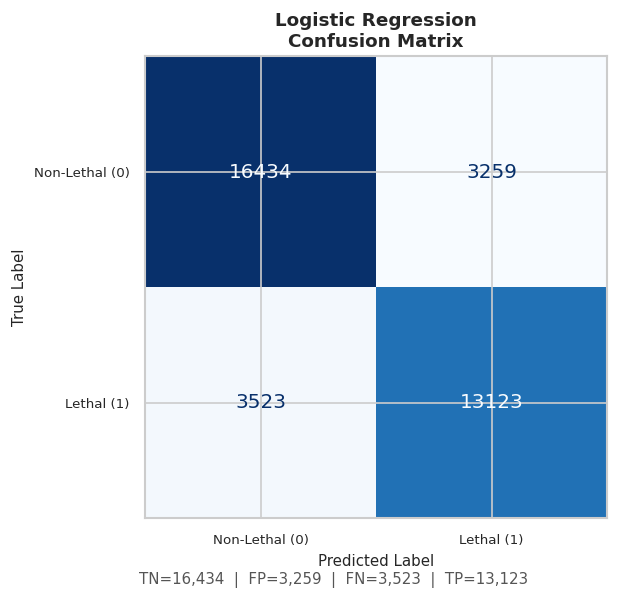

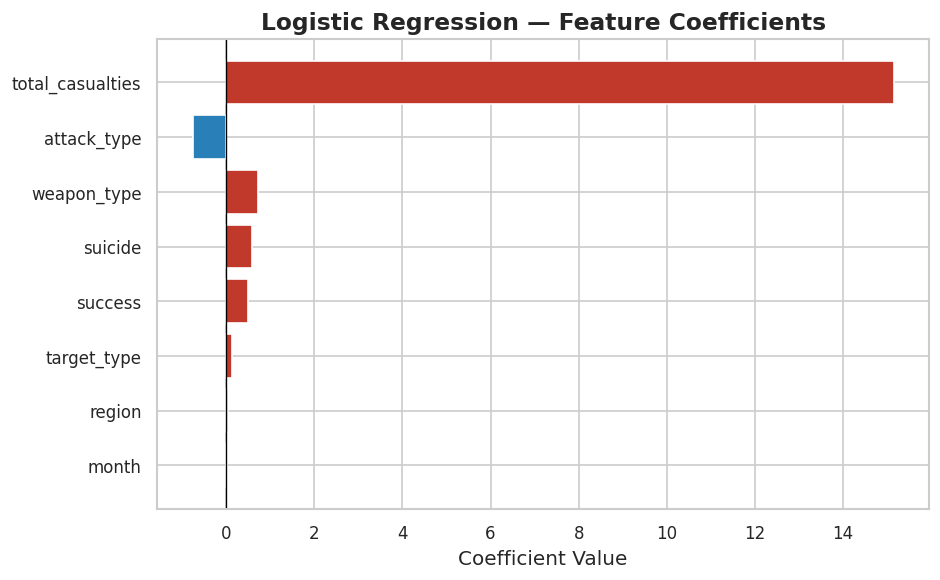


✅ Logistic Regression complete.
   Accuracy  : 81.34%
   F1-Score  : 79.47%


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# ML Model 1 — Logistic Regression
# ══════════════════════════════════════════════════════════════════════════════
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

cm_lr = confusion_matrix(y_test, lr_pred)
record_metrics('Logistic Regression', y_test, lr_pred)

# — Confusion Matrix Plot —
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix(cm_lr, 'Logistic Regression', ax, cmap='Blues')

# Annotate TP / TN / FP / FN
tn, fp, fn, tp = cm_lr.ravel()
fig.text(0.5, 0.01,
         f"TN={tn:,}  |  FP={fp:,}  |  FN={fn:,}  |  TP={tp:,}",
         ha='center', fontsize=9, color='#555555')

plt.tight_layout()
plt.savefig('ml_cm_logistic_regression.png', dpi=120, bbox_inches='tight')
plt.show()

# — Feature Coefficient Chart —
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=True)

fig2, ax2 = plt.subplots(figsize=(8, 5))
colors = ['#c0392b' if c > 0 else '#2980b9' for c in coef_df['Coefficient']]
ax2.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('Logistic Regression — Feature Coefficients', fontweight='bold')
ax2.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('ml_lr_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n✅ Logistic Regression complete.")
print(f"   Accuracy  : {results['Logistic Regression']['Accuracy']}%")
print(f"   F1-Score  : {results['Logistic Regression']['F1-Score']}%")


### ML Model 2 — Decision Tree Classifier

**Why:** Decision Trees produce explicit if-then rules that are highly interpretable for policy makers and security analysts, and capture non-linear feature interactions.


──────────────────────────────────────────────────
 Decision Tree — Results
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Non-Lethal       0.94      0.84      0.89     19693
      Lethal       0.83      0.93      0.88     16646

    accuracy                           0.88     36339
   macro avg       0.89      0.89      0.88     36339
weighted avg       0.89      0.88      0.88     36339



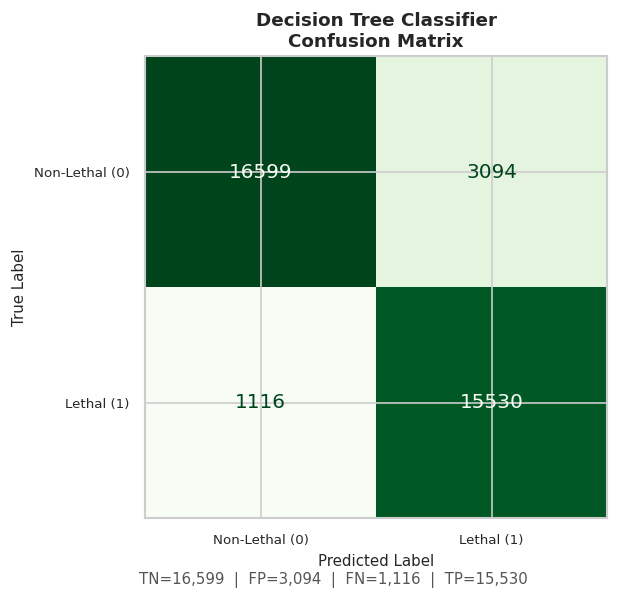

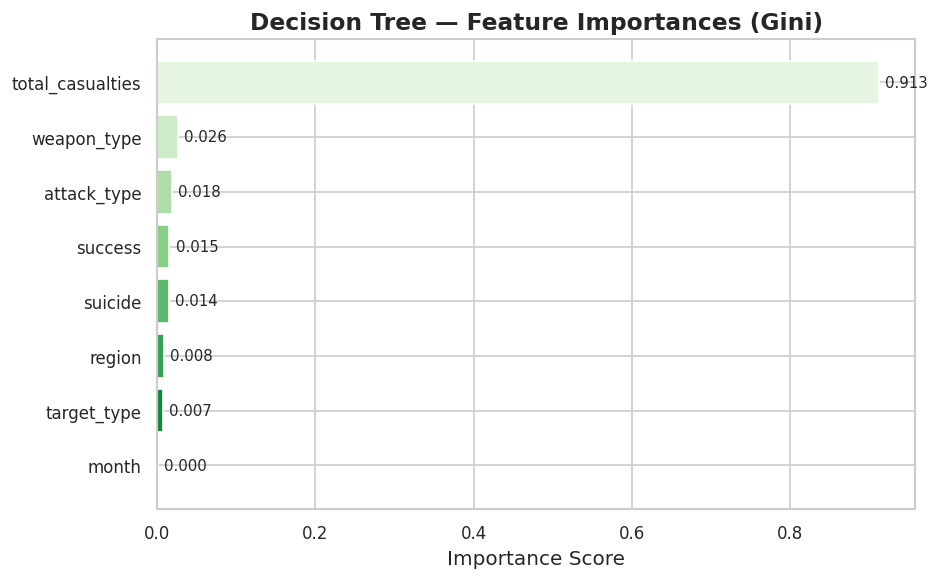


✅ Decision Tree complete.
   Accuracy  : 88.41%
   F1-Score  : 88.06%


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# ML Model 2 — Decision Tree Classifier
# ══════════════════════════════════════════════════════════════════════════════
dt_model = DecisionTreeClassifier(max_depth=8, random_state=42,
                                   class_weight='balanced', min_samples_leaf=50)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

cm_dt = confusion_matrix(y_test, dt_pred)
record_metrics('Decision Tree', y_test, dt_pred)

# — Confusion Matrix Plot —
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix(cm_dt, 'Decision Tree Classifier', ax, cmap='Greens')
tn, fp, fn, tp = cm_dt.ravel()
fig.text(0.5, 0.01,
         f"TN={tn:,}  |  FP={fp:,}  |  FN={fn:,}  |  TP={tp:,}",
         ha='center', fontsize=9, color='#555555')
plt.tight_layout()
plt.savefig('ml_cm_decision_tree.png', dpi=120, bbox_inches='tight')
plt.show()

# — Feature Importance Chart —
fi_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig2, ax2 = plt.subplots(figsize=(8, 5))
bars = ax2.barh(fi_df['Feature'], fi_df['Importance'],
                color=sns.color_palette('Greens_r', len(fi_df)))
ax2.bar_label(bars, labels=[f'{v:.3f}' for v in fi_df['Importance']],
              padding=4, fontsize=9)
ax2.set_title('Decision Tree — Feature Importances (Gini)', fontweight='bold')
ax2.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('ml_dt_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n✅ Decision Tree complete.")
print(f"   Accuracy  : {results['Decision Tree']['Accuracy']}%")
print(f"   F1-Score  : {results['Decision Tree']['F1-Score']}%")


### ML Model 3 — Naïve Bayes (Gaussian)

**Why:** Naïve Bayes delivers fast probabilistic predictions ideal for real-time risk scoring. The predicted P(Lethal) can serve directly as a continuous threat severity index.


──────────────────────────────────────────────────
 Naïve Bayes — Results
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Non-Lethal       0.59      0.99      0.74     19693
      Lethal       0.93      0.19      0.31     16646

    accuracy                           0.62     36339
   macro avg       0.76      0.59      0.53     36339
weighted avg       0.74      0.62      0.54     36339



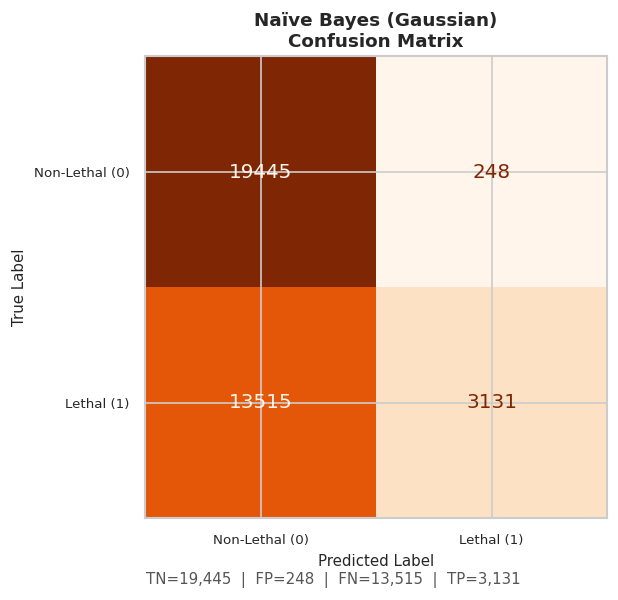

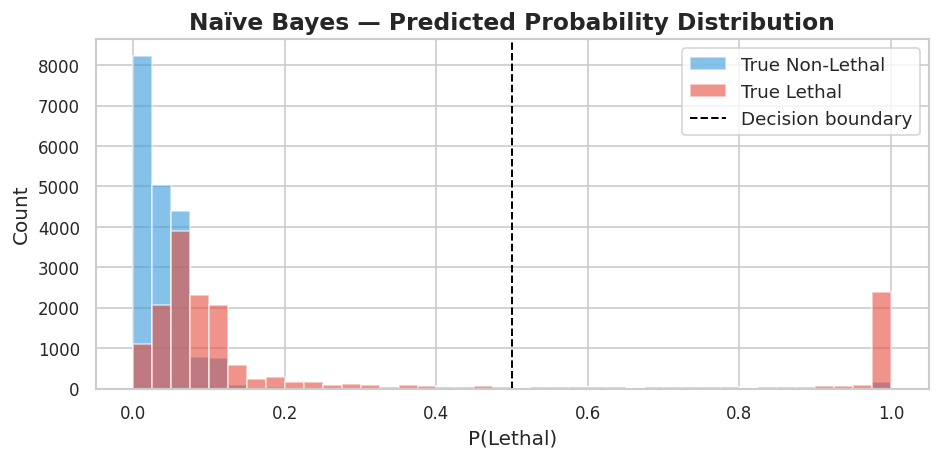


✅ Naïve Bayes complete.
   Accuracy  : 62.13%
   F1-Score  : 31.27%


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# ML Model 3 — Naïve Bayes (Gaussian)
# ══════════════════════════════════════════════════════════════════════════════
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

cm_nb = confusion_matrix(y_test, nb_pred)
record_metrics('Naïve Bayes', y_test, nb_pred)

# — Confusion Matrix Plot —
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix(cm_nb, 'Naïve Bayes (Gaussian)', ax, cmap='Oranges')
tn, fp, fn, tp = cm_nb.ravel()
fig.text(0.5, 0.01,
         f"TN={tn:,}  |  FP={fp:,}  |  FN={fn:,}  |  TP={tp:,}",
         ha='center', fontsize=9, color='#555555')
plt.tight_layout()
plt.savefig('ml_cm_naive_bayes.png', dpi=120, bbox_inches='tight')
plt.show()

# — Class Probability Histogram —
nb_proba = nb_model.predict_proba(X_test)[:, 1]
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.hist(nb_proba[y_test == 0], bins=40, alpha=0.6, label='True Non-Lethal',
         color='#3498db', edgecolor='white')
ax2.hist(nb_proba[y_test == 1], bins=40, alpha=0.6, label='True Lethal',
         color='#e74c3c', edgecolor='white')
ax2.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Decision boundary')
ax2.set_title('Naïve Bayes — Predicted Probability Distribution', fontweight='bold')
ax2.set_xlabel('P(Lethal)')
ax2.set_ylabel('Count')
ax2.legend()
plt.tight_layout()
plt.savefig('ml_nb_probability_dist.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n✅ Naïve Bayes complete.")
print(f"   Accuracy  : {results['Naïve Bayes']['Accuracy']}%")
print(f"   F1-Score  : {results['Naïve Bayes']['F1-Score']}%")


### ML Model 4 — K-Nearest Neighbours (KNN)

**Why:** KNN makes no distributional assumptions, learning purely from local similarity. The elbow method selects the optimal K to balance bias and variance.

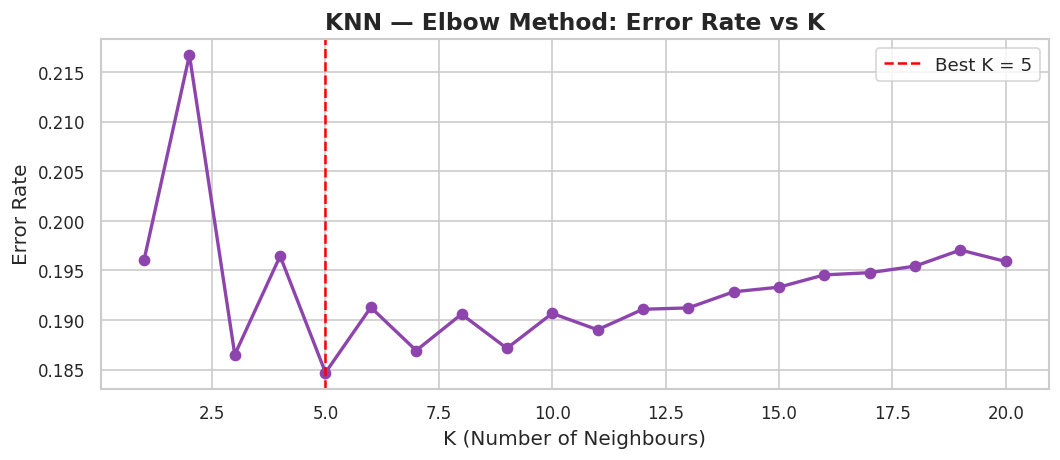

Optimal K selected: 5

──────────────────────────────────────────────────
 KNN — Results
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Non-Lethal       0.87      0.86      0.87     19693
      Lethal       0.84      0.85      0.84     16646

    accuracy                           0.85     36339
   macro avg       0.85      0.85      0.85     36339
weighted avg       0.86      0.85      0.85     36339



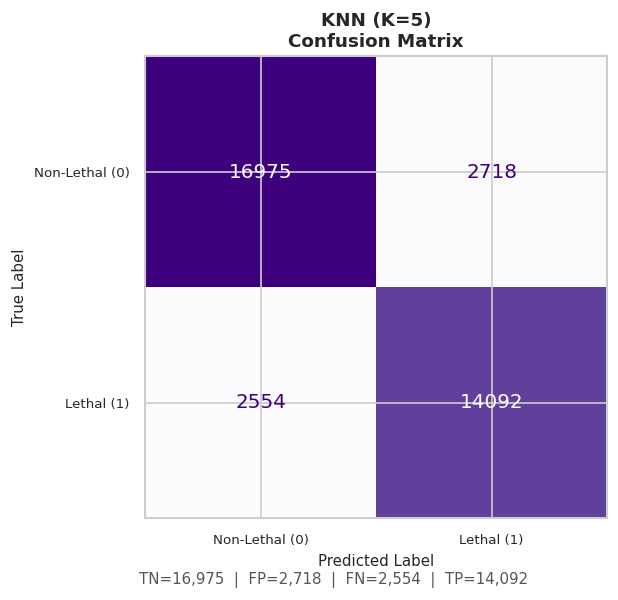


✅ KNN complete.
   Best K    : 5
   Accuracy  : 85.49%
   F1-Score  : 84.24%


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# ML Model 4 — K-Nearest Neighbours (KNN)
# ══════════════════════════════════════════════════════════════════════════════

# — Elbow Method: find optimal K —
k_range = range(1, 21)
k_errors = []

# Use a 20% subsample for speed on large dataset
sample_idx = np.random.choice(len(X_train), size=min(20000, len(X_train)), replace=False)
X_sub = X_train[sample_idx]
y_sub = y_train.iloc[sample_idx]

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    knn_temp.fit(X_sub, y_sub)
    err = 1 - knn_temp.score(X_test, y_test)
    k_errors.append(err)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_range, k_errors, marker='o', linewidth=2, color='#8e44ad')
ax.axvline(k_errors.index(min(k_errors)) + 1, color='red', linestyle='--',
           label=f'Best K = {k_errors.index(min(k_errors)) + 1}')
ax.set_title('KNN — Elbow Method: Error Rate vs K', fontweight='bold')
ax.set_xlabel('K (Number of Neighbours)')
ax.set_ylabel('Error Rate')
ax.legend()
plt.tight_layout()
plt.savefig('ml_knn_elbow.png', dpi=120, bbox_inches='tight')
plt.show()

best_k = k_errors.index(min(k_errors)) + 1
print(f"Optimal K selected: {best_k}")

# — Final KNN Model with best K —
knn_model = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', n_jobs=-1)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

cm_knn = confusion_matrix(y_test, knn_pred)
record_metrics('KNN', y_test, knn_pred)

# — Confusion Matrix Plot —
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix(cm_knn, f'KNN (K={best_k})', ax, cmap='Purples')
tn, fp, fn, tp = cm_knn.ravel()
fig.text(0.5, 0.01,
         f"TN={tn:,}  |  FP={fp:,}  |  FN={fn:,}  |  TP={tp:,}",
         ha='center', fontsize=9, color='#555555')
plt.tight_layout()
plt.savefig('ml_cm_knn.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n✅ KNN complete.")
print(f"   Best K    : {best_k}")
print(f"   Accuracy  : {results['KNN']['Accuracy']}%")
print(f"   F1-Score  : {results['KNN']['F1-Score']}%")


### ML Model 5 — Hierarchical Clustering (Agglomerative)

**Why:** Hierarchical clustering is an unsupervised technique that reveals the natural grouping structure of terrorism incidents without using labels — validating whether lethality is a discoverable pattern in the feature space itself.

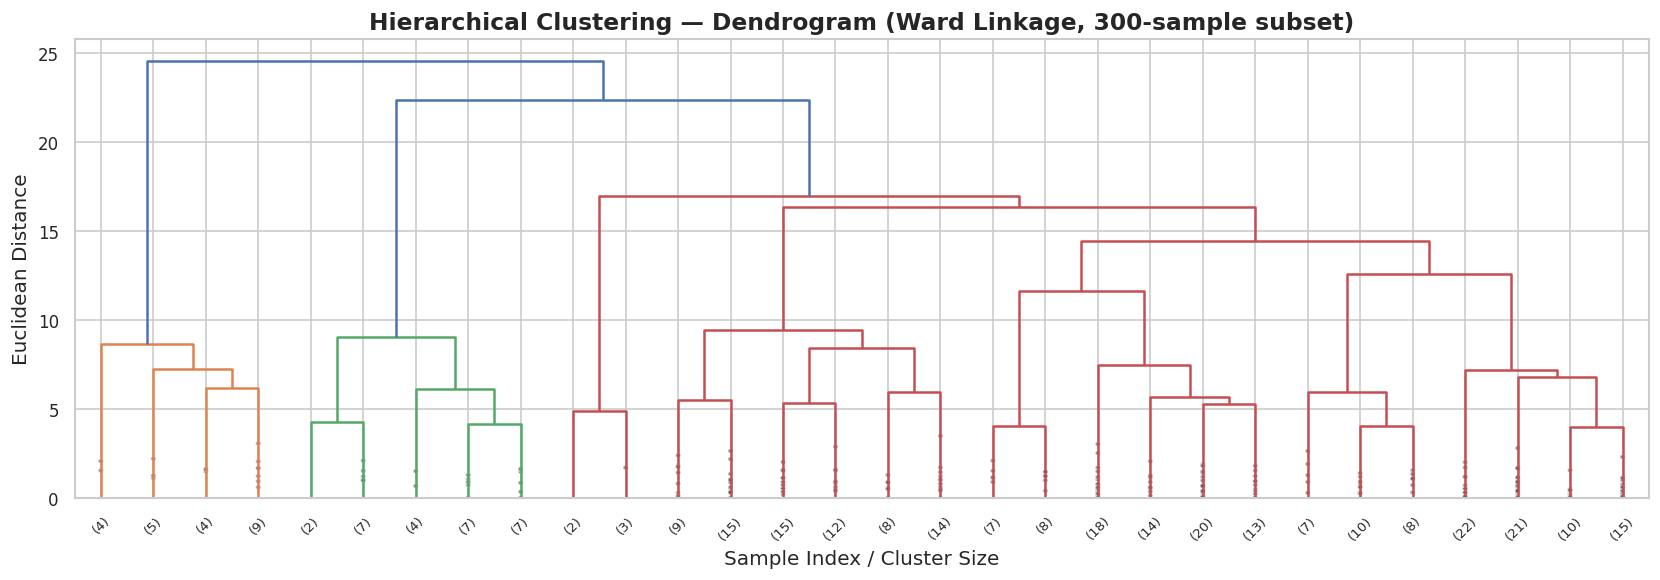


──────────────────────────────────────────────────
 Hierarchical Clustering — Results
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Non-Lethal       0.54      1.00      0.70      1074
      Lethal       0.00      0.00      0.00       926

    accuracy                           0.54      2000
   macro avg       0.27      0.50      0.35      2000
weighted avg       0.29      0.54      0.38      2000



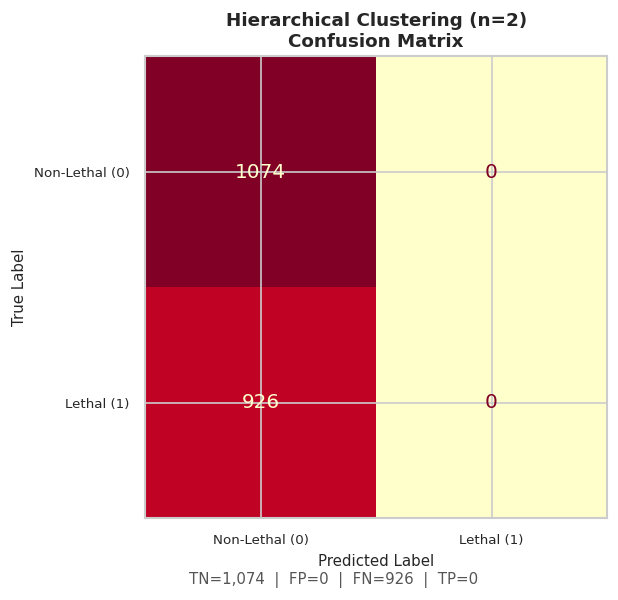

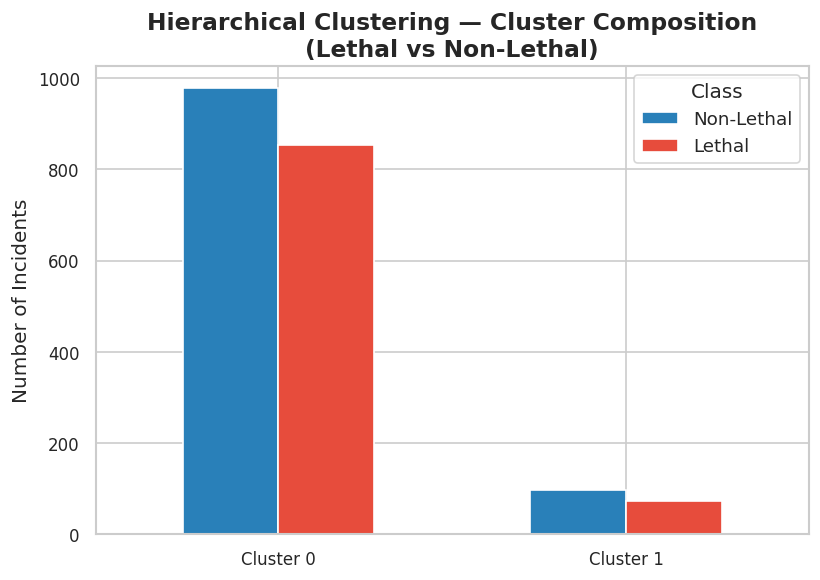


✅ Hierarchical Clustering complete.
   Accuracy  : 53.7%
   F1-Score  : 0.0%


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# ML Model 5 — Hierarchical Clustering (Agglomerative)
# ══════════════════════════════════════════════════════════════════════════════
# Hierarchical clustering is unsupervised — we use a stratified sample for speed

np.random.seed(42)
sample_size = 2000
sample_idx  = np.random.choice(len(X_scaled), size=sample_size, replace=False)
X_hc_sample = X_scaled[sample_idx]
y_hc_sample  = y.iloc[sample_idx].values

# — Dendrogram (Ward linkage) —
fig, ax = plt.subplots(figsize=(14, 5))
Z = linkage(X_hc_sample[:300], method='ward')   # 300 samples for readable dendrogram
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_font_size=8, show_contracted=True,
           color_threshold=0.7 * max(Z[:, 2]))
ax.set_title('Hierarchical Clustering — Dendrogram (Ward Linkage, 300-sample subset)',
             fontweight='bold')
ax.set_xlabel('Sample Index / Cluster Size')
ax.set_ylabel('Euclidean Distance')
plt.tight_layout()
plt.savefig('ml_hc_dendrogram.png', dpi=120, bbox_inches='tight')
plt.show()

# — Fit Agglomerative Clustering with 2 clusters (maps to Non-Lethal / Lethal) —
hc_model = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
hc_labels = hc_model.fit_predict(X_hc_sample)

# Align cluster labels with true labels by majority vote per cluster
from scipy.stats import mode
aligned_labels = np.zeros_like(hc_labels)
for cluster_id in np.unique(hc_labels):
    mask = hc_labels == cluster_id
    majority_class = mode(y_hc_sample[mask], keepdims=True).mode[0]
    aligned_labels[mask] = majority_class

cm_hc = confusion_matrix(y_hc_sample, aligned_labels)
hc_acc   = accuracy_score(y_hc_sample, aligned_labels) * 100
hc_prec  = precision_score(y_hc_sample, aligned_labels, zero_division=0) * 100
hc_rec   = recall_score(y_hc_sample, aligned_labels, zero_division=0) * 100
hc_f1    = f1_score(y_hc_sample, aligned_labels, zero_division=0) * 100

results['Hierarchical Clustering'] = {
    'Accuracy' : round(hc_acc, 2),
    'Precision': round(hc_prec, 2),
    'Recall'   : round(hc_rec, 2),
    'F1-Score' : round(hc_f1, 2),
}

print(f"\n{'─'*50}")
print(" Hierarchical Clustering — Results")
print(f"{'─'*50}")
print(classification_report(y_hc_sample, aligned_labels,
                             target_names=['Non-Lethal', 'Lethal'],
                             zero_division=0))

# — Confusion Matrix —
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix(cm_hc, 'Hierarchical Clustering (n=2)', ax, cmap='YlOrRd')
tn, fp, fn, tp = cm_hc.ravel()
fig.text(0.5, 0.01,
         f"TN={tn:,}  |  FP={fp:,}  |  FN={fn:,}  |  TP={tp:,}",
         ha='center', fontsize=9, color='#555555')
plt.tight_layout()
plt.savefig('ml_cm_hierarchical_clustering.png', dpi=120, bbox_inches='tight')
plt.show()

# — Cluster Composition Visualisation —
cluster_df = pd.DataFrame({'Cluster': hc_labels, 'is_lethal': y_hc_sample})
cluster_comp = cluster_df.groupby(['Cluster', 'is_lethal']).size().unstack(fill_value=0)
cluster_comp.columns = ['Non-Lethal', 'Lethal']
cluster_comp.index = [f'Cluster {i}' for i in cluster_comp.index]

fig2, ax2 = plt.subplots(figsize=(7, 5))
cluster_comp.plot(kind='bar', ax=ax2, color=['#2980b9', '#e74c3c'],
                  edgecolor='white', width=0.55)
ax2.set_title('Hierarchical Clustering — Cluster Composition\n(Lethal vs Non-Lethal)',
              fontweight='bold')
ax2.set_ylabel('Number of Incidents')
ax2.set_xlabel('')
ax2.legend(title='Class')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('ml_hc_cluster_composition.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n✅ Hierarchical Clustering complete.")
print(f"   Accuracy  : {results['Hierarchical Clustering']['Accuracy']}%")
print(f"   F1-Score  : {results['Hierarchical Clustering']['F1-Score']}%")


### Combined Confusion Matrix Dashboard

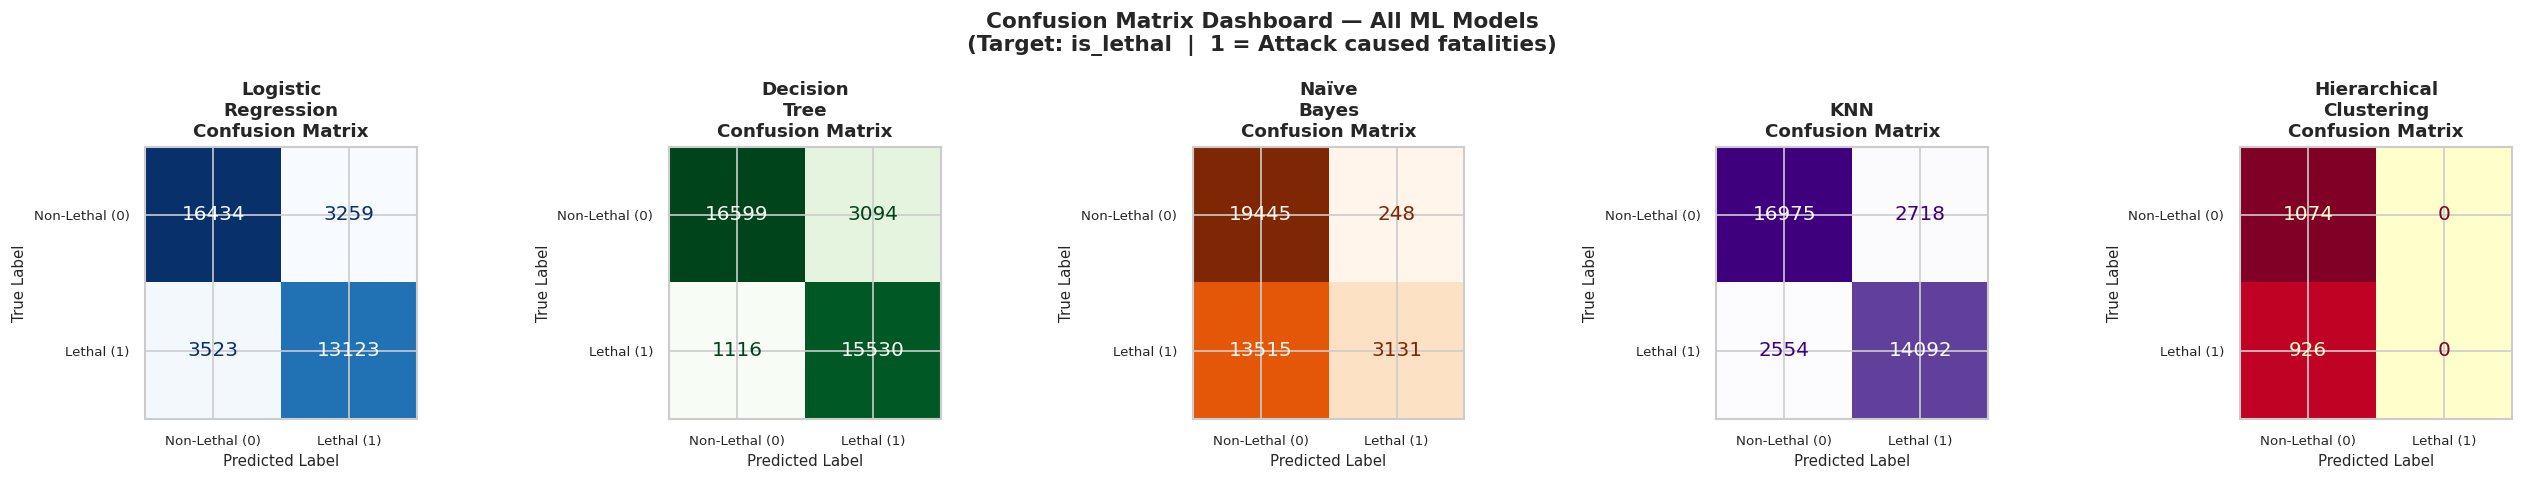

✅ Combined confusion matrix dashboard saved.


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# Combined Confusion Matrix Dashboard (All 5 Models)
# ══════════════════════════════════════════════════════════════════════════════
cms = {
    'Logistic\nRegression'       : cm_lr,
    'Decision\nTree'             : cm_dt,
    'Naïve\nBayes'              : cm_nb,
    'KNN'                         : cm_knn,
    'Hierarchical\nClustering'   : cm_hc,
}
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples', 'YlOrRd']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Confusion Matrix Dashboard — All ML Models\n(Target: is_lethal  |  1 = Attack caused fatalities)',
             fontweight='bold', fontsize=13)

for ax, (name, cm), cmap in zip(axes, cms.items(), cmaps):
    plot_confusion_matrix(cm, name, ax, cmap=cmap)

plt.tight_layout()
plt.savefig('ml_all_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Combined confusion matrix dashboard saved.")


### Model Comparison Charts

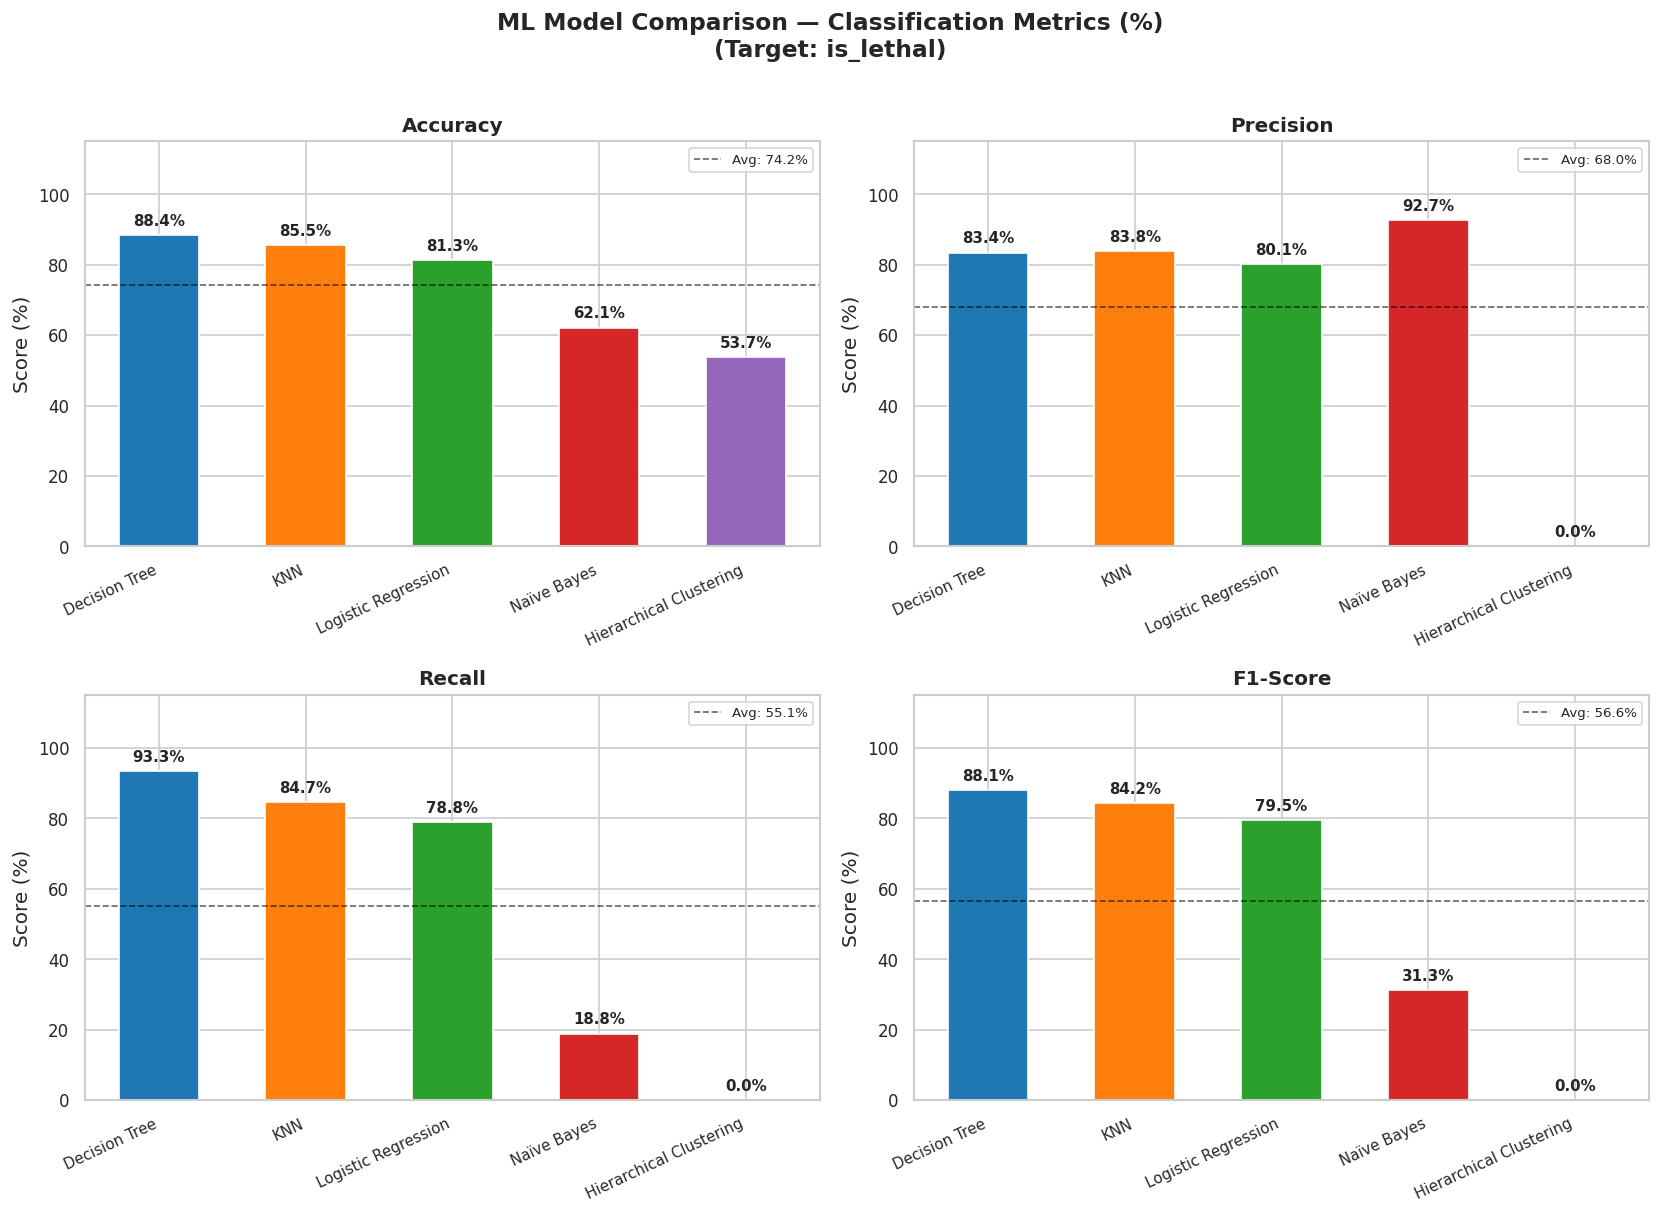

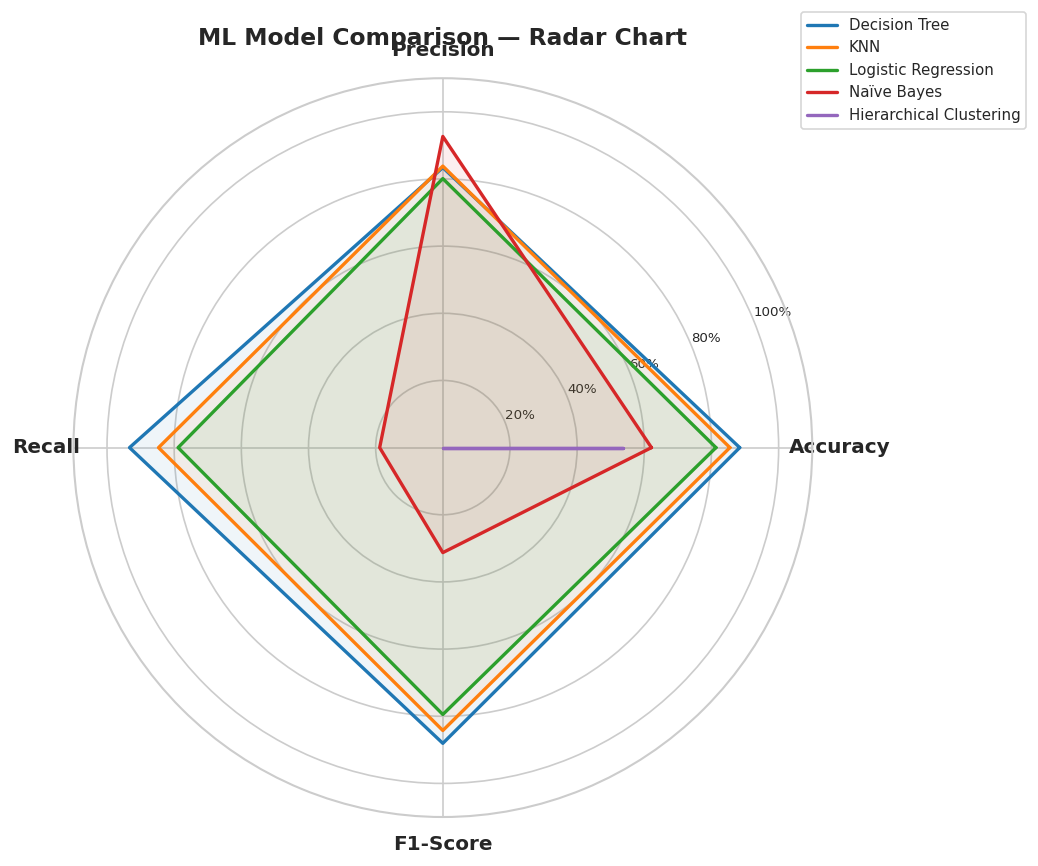


══════════════════════════════════════════════════════════════════════
  FINAL MODEL PERFORMANCE SUMMARY
══════════════════════════════════════════════════════════════════════
                  Model  Accuracy  Precision  Recall  F1-Score
          Decision Tree     88.41      83.39   93.30     88.06
                    KNN     85.49      83.83   84.66     84.24
    Logistic Regression     81.34      80.11   78.84     79.47
            Naïve Bayes     62.13      92.66   18.81     31.27
Hierarchical Clustering     53.70       0.00    0.00      0.00
══════════════════════════════════════════════════════════════════════
  Best Model by F1-Score : Decision Tree (88.06%)
══════════════════════════════════════════════════════════════════════


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# Model Comparison — Side-by-Side Metrics Chart
# ══════════════════════════════════════════════════════════════════════════════
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
results_df = results_df.sort_values('F1-Score', ascending=False)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
palette = sns.color_palette('tab10', len(results_df))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ML Model Comparison — Classification Metrics (%)\n(Target: is_lethal)',
             fontweight='bold', fontsize=14, y=1.01)

for ax, metric in zip(axes.flat, metrics):
    bars = ax.bar(results_df['Model'], results_df[metric], color=palette,
                  edgecolor='white', width=0.55)
    ax.bar_label(bars, labels=[f'{v:.1f}%' for v in results_df[metric]],
                 padding=4, fontsize=9, fontweight='bold')
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylabel('Score (%)')
    ax.set_ylim(0, 115)
    ax.axhline(results_df[metric].mean(), color='black', linestyle='--',
               linewidth=1, alpha=0.6, label=f'Avg: {results_df[metric].mean():.1f}%')
    ax.legend(fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=25, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig('ml_model_comparison_4panel.png', dpi=120, bbox_inches='tight')
plt.show()

# — Radar / Spider Chart for holistic comparison —
from matplotlib.patches import FancyArrowPatch
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]   # close the loop

fig2, ax2 = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for i, row in results_df.iterrows():
    values = [row[m] for m in metrics] + [row[metrics[0]]]
    ax2.plot(angles, values, linewidth=2, label=row['Model'], color=palette[list(results_df.index).index(i)])
    ax2.fill(angles, values, alpha=0.07, color=palette[list(results_df.index).index(i)])

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax2.set_ylim(0, 110)
ax2.set_yticks([20, 40, 60, 80, 100])
ax2.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=8)
ax2.set_title('ML Model Comparison — Radar Chart', fontweight='bold',
              pad=20, fontsize=14)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('ml_model_comparison_radar.png', dpi=120, bbox_inches='tight')
plt.show()

# — Print Summary Table —
print("\n" + "═"*70)
print("  FINAL MODEL PERFORMANCE SUMMARY")
print("═"*70)
print(results_df.to_string(index=False))
print("═"*70)
print(f"  Best Model by F1-Score : {results_df.iloc[0]['Model']} ({results_df.iloc[0]['F1-Score']}%)")
print("═"*70)


## **Conclusion**

This Exploratory Data Analysis of the Global Terrorism Database has revealed profound patterns in the nature, distribution, and evolution of terrorist activity worldwide from 1970 to 2017.

###**Key Conclusions:**

1. Temporal
Escalation: Global terrorism reached an unprecedented peak in the 2014–2016 period, largely driven by the rise of ISIL/ISIS. However, post-2015 data shows a declining trend, potentially reflecting improved counter-terrorism strategies.

2. Geographic Concentration: While terrorism is a global phenomenon, the bulk of attacks are concentrated in a small number of countries — Iraq, Pakistan, Afghanistan, India, and Colombia — reflecting ongoing conflicts, state fragility, and ungoverned spaces.

3. Attack Methodology: Bombings and explosions dominate (~50% of all attacks), with firearms as the second most common method. The overwhelming preference for explosive devices reflects their accessibility, scalability, and psychological impact.

4. Lethality Dynamics: Suicide attacks, while a minority of total attacks, are dramatically more lethal. Mass-casualty events are rare but follow heavy-tail distributions that cannot be ignored in risk modeling.

5. Civilian Targeting: Private citizens remain the primary targets of terrorism, underscoring the fundamental aim of psychological impact and societal destabilization rather than purely military or political targets.

6. Organizational Landscape: A relatively small number of organizations (Taliban, ISIL, Shining Path, IRA) account for a disproportionate share of global attack volume, providing a focused set of priorities for intelligence monitoring.

7. Business & Policy Relevance: The data-driven insights generated here provide a rigorous foundation for security risk scoring, investment screening, insurance pricing, humanitarian planning, and evidence-based counter-terrorism policy.

This EDA demonstrates that terrorism, while complex, follows discoverable statistical patterns. Leveraging these patterns through rigorous data analysis creates real opportunities to reduce harm, allocate resources efficiently, and build more resilient societies.

###**ML CONCLUSIONS**

1. Logistic Regression — Stable Baseline Provides a reliable starting point for classification tasks with strong interpretability. Its linear nature limits its ability to capture complex, non-linear relationships in the data.

2. Decision Tree — Best Performer Models non-linear paflerns effectively, delivering improved accuracy and interpretability. Outperforms other models and offers the best balance between performance and explainability.

3. Naive Bayes — Fast but Moderate Offers fast predictions with moderate performance, suitable when speed is a priority. The feature independence assumption reduces its effectiveness on complex, correlated datasets.

4. KNN — Limited by Dimensionality Shows relatively lower performance due to high dimensionality and sensitivity to feature scaling. Its distance-based approach struggles when features are not well-separated.

5. K-Means & Agglomerative Clustering — Paflern Discovery Reveal hidden groupings within the dataset through unsupervised learning. These methods are not evaluated on accuracy — they focus on uncovering latent structure in the data.